# **Проект: Прогнозирование вероятности отмены бронирования в сети отелей**

## Постановка задачи

Цель проекта — разработать модель машинного обучения, способную прогнозировать вероятность отмены бронирования клиентом до даты заезда. Такая модель позволит сети отелей заранее выявлять бронирования с высоким риском отмены и принимать управленческие решения, например, повторно выставлять номера на продажу или сохранять текущую бронь.

Помимо достижения высокого качества классификации, важной задачей проекта является оценка экономической эффективности внедрения модели. Для этого необходимо рассчитать влияние модели на бизнес-показатели: долю отмен бронирований, загрузку отелей и прирост дохода (Incremental Revenue). Итоговая модель должна не только корректно прогнозировать отмены, но и обеспечивать экономическую выгоду для сети отелей.

## Описание данных

Для решения задачи используются данные из базы данных PostgreSQL, представленные двумя таблицами:

* **hotel_bookings** — содержит информацию о бронированиях, включая сведения о клиентах, датах бронирования и заезда, характеристиках номера, стоимости проживания и факте отмены бронирования (целевой признак).
* **hotel_reviews** — содержит отзывы клиентов, включая дату публикации отзыва, текст комментария и числовую оценку проживания.

На этапе подготовки данных таблицы будут объединены таким образом, чтобы для каждого бронирования был выбран последний отзыв клиента, оставленный до даты данного бронирования. Это позволит использовать информацию о предыдущем опыте проживания клиента в качестве дополнительных признаков при построении модели. Также в ходе проекта будут выполнены исследовательский анализ данных, создание новых признаков, обработка текстовых отзывов с использованием методов векторизации и обучение нескольких моделей машинного обучения с последующей оценкой их экономической эффективности.


## Перевод бизнес-задачи на язык машинного обучения

### План решения задачи

Для решения задачи будет применён подход машинного обучения для бинарной классификации, где целевой переменной является факт отмены бронирования.

На первом этапе будет выполнена подготовка данных: исследовательский анализ, обработка пропусков и аномалий, объединение таблиц бронирований и отзывов, а также создание новых признаков на основе имеющихся данных. Для текстовых отзывов будет использована векторизация методом **TF-IDF**, что позволит преобразовать текстовую информацию в числовые признаки, пригодные для обучения моделей. 

Для построения моделей будут использованы два современных алгоритма градиентного бустинга:

* **CatBoost** — модель, эффективно работающая с категориальными признаками и обладающая высокой устойчивостью к переобучению;
* **LightGBM** — быстрый и производительный алгоритм градиентного бустинга, позволяющий получать качественные результаты на больших наборах данных.

Для каждой модели будет проведён подбор гиперпараметров с использованием библиотеки **Optuna** и трёхфолдовой кросс-валидации. В качестве основной метрики оптимизации будет использоваться **Incremental Revenue (IR)**, поскольку именно она отражает экономическую эффективность модели для бизнеса. После выбора лучшей модели будет выполнена её калибровка и поиск оптимального порога классификации, максимизирующего значение IR. 

На заключительном этапе будет проведена оценка качества модели на тестовой выборке, анализ важности признаков и расчёт ключевых бизнес-показателей до и после внедрения модели, что позволит оценить целесообразность её использования в работе сети отелей. 


## Загрузка необходимых библиотек

In [1]:
!pip install optuna -q

In [2]:
!pip install shap -q

In [3]:
!pip install phik -q

In [4]:
# Работа с данными
import numpy as np
import pandas as pd

# Визуализация
import matplotlib.pyplot as plt
import seaborn as sns

# Подключение к PostgreSQL
from sqlalchemy import create_engine

# Обработка текста
from sklearn.feature_extraction.text import TfidfVectorizer

# Разделение данных
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    TimeSeriesSplit 
)

# Метрики
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    brier_score_loss
)

# Калибровка модели
from sklearn.calibration import CalibratedClassifierCV

# Модели
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

from sklearn.model_selection import StratifiedShuffleSplit

# Подбор гиперпараметров
import optuna

# Анализ важности признаков
import shap

from phik import phik_matrix

import nltk
from nltk.corpus import stopwords

import joblib

# Дополнительные настройки
import warnings
warnings.filterwarnings('ignore')

import os
# Настройки отображения
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('ggplot')

In [5]:
pd.set_option('display.max_colwidth', None)

## Этап 1: подготовка данных

### Загрузка данных

In [6]:
db_config = {
    "host": os.getenv("DB_HOST"),
    "port": os.getenv("DB_PORT"),
    "database": os.getenv("DB_NAME"),
    "user": os.getenv("DB_USER"),
    "password": os.getenv("DB_PASSWORD"),
}

In [7]:
connection_string = (
    f"postgresql://{db_config['user']}:{db_config['password']}"
    f"@{db_config['host']}:{db_config['port']}/{db_config['database']}"
)

In [8]:
engine = create_engine(connection_string)

In [9]:
bookings = pd.read_sql_query(
    "SELECT * FROM hotel_bookings;",
    con=engine
)

In [10]:
reviews = pd.read_sql_query(
    "SELECT * FROM hotel_reviews;",
    con=engine
)

In [11]:
bookings.head()

,booking_id,booking_date,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_status,booking_value,days_until_checkin,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests
0,INN00000,2020-07-08,корпоративное_бронирование,300,0,False,0,0,нет_отказа,6700.0,21,1,0,тип_питания_2,False,тип_1,0
1,INN00001,2021-09-19,корпоративное_бронирование,3,0,True,0,1,нет_отказа,62300.0,15,5,2,тип_питания_2,False,тип_1,1
2,INN00002,2022-11-19,корпоративное_бронирование,3,0,True,0,2,нет_отказа,46900.0,96,5,2,тип_питания_1,False,тип_1,0
3,INN00003,2017-02-11,онлайн_бронирование,2,0,False,0,0,нет_отказа,53600.0,150,6,2,тип_питания_1,False,тип_1,0
4,INN00004,2019-03-06,корпоративное_бронирование,1,0,True,1,1,нет_отказа,46900.0,96,5,2,тип_питания_1,False,тип_1,1


In [12]:
reviews.head()

,customer_id,booking_id,review_date,stay_rating,review_text
0,C0001,INN00000,2020-08-21,3,"Неплохо. тихо и спокойно, но отсутствие фена в номере. Кондиционер не справлялся, тяжело в номере"
1,C0001,INN00001,2021-10-15,3,"Неплохо. красивое оформление территории, но неработающий лифт."
2,C0001,INN00002,2023-03-08,4,Отличный отель! удобные парковочные места. здесь всегда ждут как родных
3,C0002,INN00003,2017-08-13,3,"Неплохо. тёплый приём, но неисправная сантехника. В номерах холодно. второго одеяла пришлось выпрашивать"
4,C0003,INN00004,2019-07-12,4,Отличный отель! качественная косметика в ванной. сервис здесь — это забота на максимум


### Исследовательский анализ данных и предобработка

In [13]:
def eda(df):

    print("=" * 80)
    print("ОБЩАЯ ИНФОРМАЦИЯ О ДАТАСЕТЕ")
    print("=" * 80)

    print(f"Размер данных: {df.shape[0]} строк, {df.shape[1]} столбцов\n")

    print("Первые 5 строк:")
    display(df.head())


    # ---------------------------------------------------
    # Информация о типах данных
    # ---------------------------------------------------

    print("\n" + "=" * 80)
    print("ТИПЫ ДАННЫХ")
    print("=" * 80)

    info = pd.DataFrame({
        "Тип данных": df.dtypes,
        "Количество уникальных": df.nunique(),
        "Пропуски": df.isna().sum(),
        "% пропусков": (df.isna().mean() * 100).round(2)
    })

    display(info)


    # ---------------------------------------------------
    # Дубликаты
    # ---------------------------------------------------

    print("\n" + "=" * 80)
    print("ДУБЛИКАТЫ")
    print("=" * 80)

    duplicates = df.duplicated().sum()

    print(f"Количество полных дубликатов: {duplicates}")

    # ---------------------------------------------------
    # Статистическое описание
    # ---------------------------------------------------

    print("\n" + "=" * 80)
    print("СТАТИСТИЧЕСКОЕ ОПИСАНИЕ")
    print("=" * 80)

    display(df.describe(include="all").T)


    # ---------------------------------------------------
    # Анализ пропусков
    # ---------------------------------------------------

    print("\n" + "=" * 80)
    print("АНАЛИЗ ПРОПУСКОВ")
    print("=" * 80)

    missing = df.isna().sum()

    if missing.sum() == 0:
        print("Пропусков нет")
    else:
        display(
            pd.DataFrame({
                "Количество": missing,
                "%": (missing / len(df) * 100).round(2)
            })
            .query("Количество > 0")
        )


    # ---------------------------------------------------
    # Выбросы через IQR
    # ---------------------------------------------------

    print("\n" + "=" * 80)
    print("ПОИСК ВЫБРОСОВ (IQR)")
    print("=" * 80)

    numeric_cols = df.select_dtypes(
        include=np.number
    ).columns


    outliers = {}

    for col in numeric_cols:

        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        count = ((df[col] < lower) | 
                 (df[col] > upper)).sum()

        outliers[col] = count


    outliers_df = pd.DataFrame(
        outliers.items(),
        columns=["Признак", "Количество выбросов"]
    )

    display(outliers_df)


    # ---------------------------------------------------
    # Количественные признаки
    # ---------------------------------------------------

    print("\n" + "=" * 80)
    print("ГРАФИЧЕСКИЙ АНАЛИЗ ЧИСЛОВЫХ ПРИЗНАКОВ")
    print("=" * 80)


    for col in numeric_cols:

        fig, axes = plt.subplots(
            1, 2,
            figsize=(14, 4)
        )

        sns.histplot(
            df[col],
            kde=True,
            ax=axes[0]
        )

        axes[0].set_title(
            f"Распределение {col}"
        )


        sns.boxplot(
            x=df[col],
            ax=axes[1]
        )

        axes[1].set_title(
            f"Boxplot {col}"
        )


        plt.show()



    # ---------------------------------------------------
    # Категориальные признаки
    # ---------------------------------------------------

    print("\n" + "=" * 80)
    print("ГРАФИЧЕСКИЙ АНАЛИЗ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ")
    print("=" * 80)


    categorical_cols = df.select_dtypes(
        include=["object", "category", "bool"]
    ).columns


    for col in categorical_cols:

        print(
            f"\nПризнак: {col}"
        )

        print(
            df[col].value_counts().head(10)
        )


        plt.figure(
            figsize=(10, 5)
        )

        order = (
            df[col]
            .value_counts()
            .head(10)
            .index
        )

        sns.countplot(
            data=df,
            x=col,
            order=order
        )

        plt.title(
            f"Распределение категорий {col}"
        )

        plt.xticks(
            rotation=45
        )

        plt.show()

    # ---------------------------------------------------
    # Корреляция Phik
    # ---------------------------------------------------

    print("\n" + "=" * 80)
    print("КОРРЕЛЯЦИЯ PHIK (ВСЕ ПРИЗНАКИ)")
    print("=" * 80)


    try:

        # ограничиваем расчет только нужными колонками
        df_phik = df.drop(columns=['booking_id']).sample(
            min(10000, len(df)),
            random_state=42
        )
        
        phik_corr = df_phik.phik_matrix(
            interval_cols=numeric_cols,
            bins=10
        )


        plt.figure(
            figsize=(12, 10)
        )


        sns.heatmap(
            phik_corr,
            annot=True,
            fmt=".2f",
            cmap="coolwarm"
        )


        plt.title(
            "Матрица корреляций Phik"
        )


        plt.show()


        # топ корреляций
        print("\nТоп-10 самых сильных зависимостей:")

        corr_pairs = (
            phik_corr
            .where(
                np.triu(
                    np.ones(phik_corr.shape),
                    k=1
                ).astype(bool)
            )
            .stack()
            .sort_values(
                ascending=False
            )
        )


        display(
            corr_pairs.head(10)
        )
        
        # топ корреляций
        if 'booking_status' in df.columns.to_list():
            
            print("\nТоп-10 самых сильных зависимостей с целевой переменной:")
        
            
            corr_pairs = (
                phik_corr['booking_status'].sort_values(ascending=False)
            )


            display(
                corr_pairs.head(10)
            )


    except Exception as e:
        print(
            "Ошибка расчета Phik:",
            e
        )



    print("\n" + "=" * 80)
    print("EDA ЗАВЕРШЕН")
    print("=" * 80)

ОБЩАЯ ИНФОРМАЦИЯ О ДАТАСЕТЕ
Размер данных: 35341 строк, 17 столбцов

Первые 5 строк:


,booking_id,booking_date,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_status,booking_value,days_until_checkin,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests
0,INN00000,2020-07-08,корпоративное_бронирование,300,0,False,0,0,нет_отказа,6700.0,21,1,0,тип_питания_2,False,тип_1,0
1,INN00001,2021-09-19,корпоративное_бронирование,3,0,True,0,1,нет_отказа,62300.0,15,5,2,тип_питания_2,False,тип_1,1
2,INN00002,2022-11-19,корпоративное_бронирование,3,0,True,0,2,нет_отказа,46900.0,96,5,2,тип_питания_1,False,тип_1,0
3,INN00003,2017-02-11,онлайн_бронирование,2,0,False,0,0,нет_отказа,53600.0,150,6,2,тип_питания_1,False,тип_1,0
4,INN00004,2019-03-06,корпоративное_бронирование,1,0,True,1,1,нет_отказа,46900.0,96,5,2,тип_питания_1,False,тип_1,1



ТИПЫ ДАННЫХ


,Тип данных,Количество уникальных,Пропуски,% пропусков
booking_id,object,30733,0,0.0
booking_date,object,2445,0,0.0
sales_channel,object,3,0,0.0
adult_count,int64,6,0,0.0
child_count,int64,3,0,0.0
returning_customer,bool,2,0,0.0
previous_cancellations,int64,6,0,0.0
previous_no_shows,int64,6,0,0.0
booking_status,object,2,0,0.0
booking_value,float64,1766,0,0.0



ДУБЛИКАТЫ
Количество полных дубликатов: 4608

СТАТИСТИЧЕСКОЕ ОПИСАНИЕ


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
booking_id,35341,30733,INN04779,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
booking_date,35341,2445,2020-09-03,39,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sales_channel,35341,3,офлайн_бронирование,12040,NaN,NaN,NaN,NaN,NaN,NaN,NaN
adult_count,35341.0,NaN,NaN,NaN,12.479726,45.72629,1.0,1.0,2.0,3.0,300.0
child_count,35341.0,NaN,NaN,NaN,0.358988,0.587324,0.0,0.0,0.0,1.0,2.0
returning_customer,35341,2,True,19928,NaN,NaN,NaN,NaN,NaN,NaN,NaN
previous_cancellations,35341.0,NaN,NaN,NaN,0.356923,0.628771,0.0,0.0,0.0,1.0,5.0
previous_no_shows,35341.0,NaN,NaN,NaN,0.839535,0.931724,0.0,0.0,1.0,1.0,5.0
booking_status,35341,2,нет_отказа,25177,NaN,NaN,NaN,NaN,NaN,NaN,NaN
booking_value,35341.0,NaN,NaN,NaN,61634.055219,42837.589968,0.0,33500.0,53600.0,80400.0,417221.2



АНАЛИЗ ПРОПУСКОВ
Пропусков нет

ПОИСК ВЫБРОСОВ (IQR)


,Признак,Количество выбросов
0,adult_count,2151
1,child_count,0
2,previous_cancellations,367
3,previous_no_shows,2137
4,booking_value,1006
5,days_until_checkin,375
6,weekday_nights,0
7,weekend_nights,1082
8,customer_special_requests,706



ГРАФИЧЕСКИЙ АНАЛИЗ ЧИСЛОВЫХ ПРИЗНАКОВ


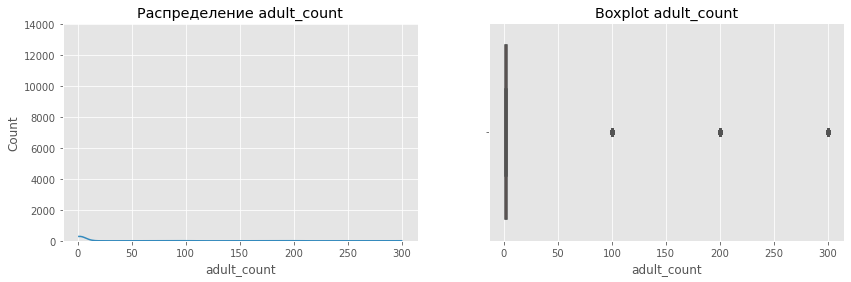

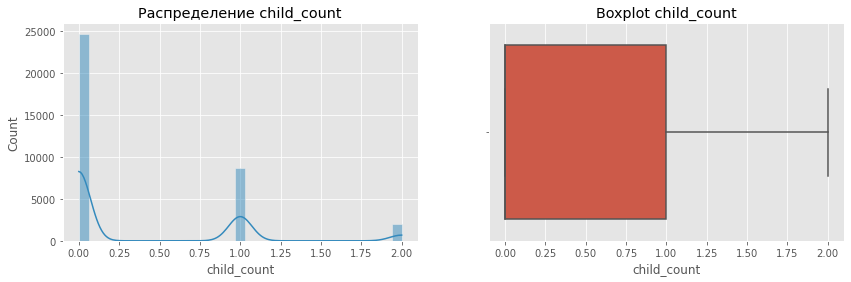

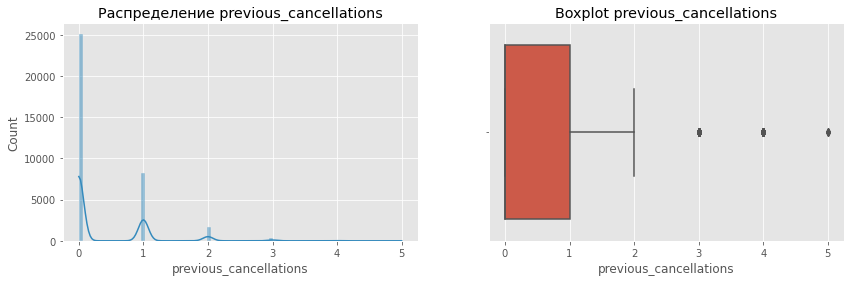

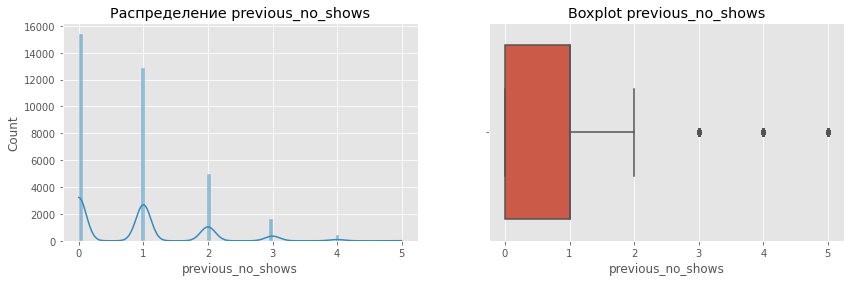

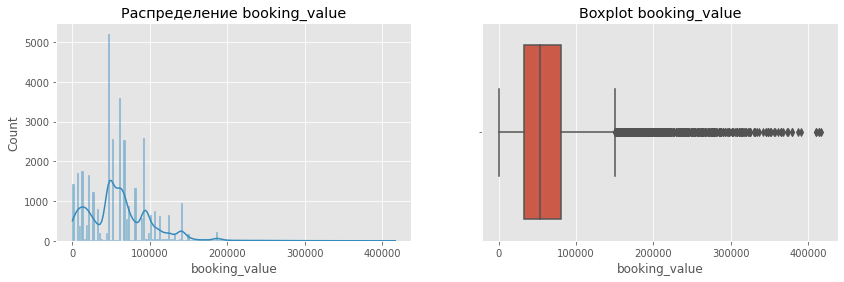

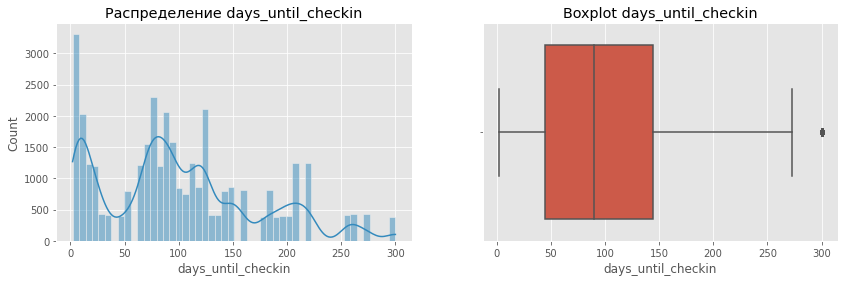

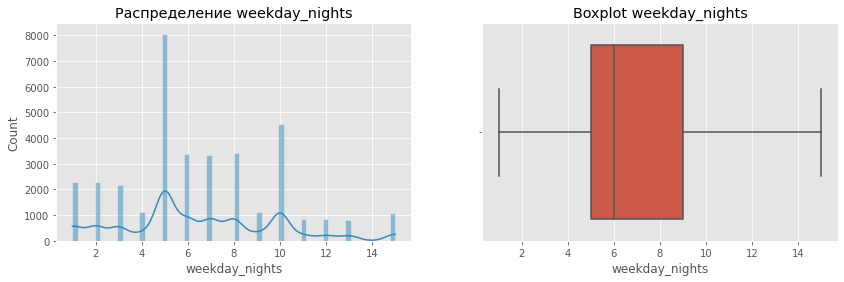

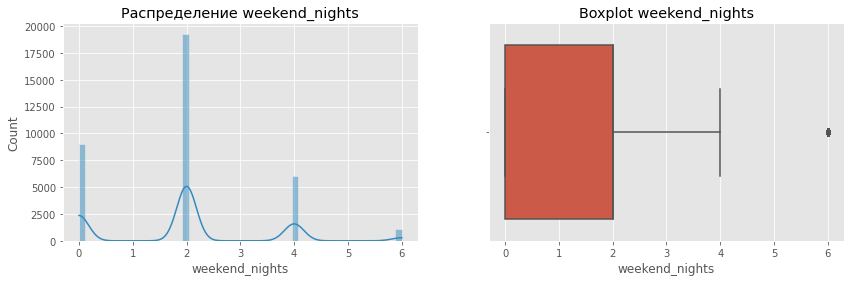

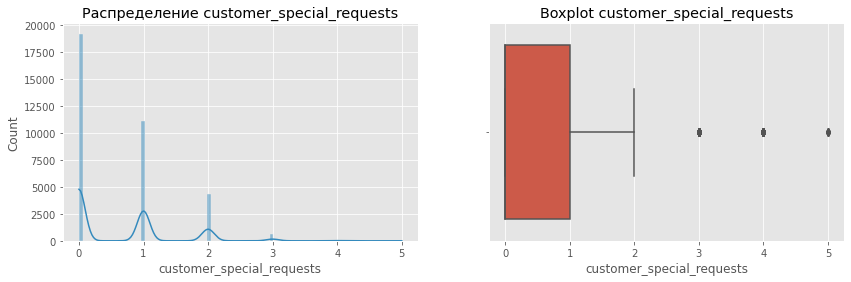


ГРАФИЧЕСКИЙ АНАЛИЗ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ

Признак: booking_id
INN04779    4
INN22303    4
INN27096    4
INN24774    4
INN17415    4
INN26876    4
INN22764    4
INN11338    4
INN14583    4
INN26398    4
Name: booking_id, dtype: int64


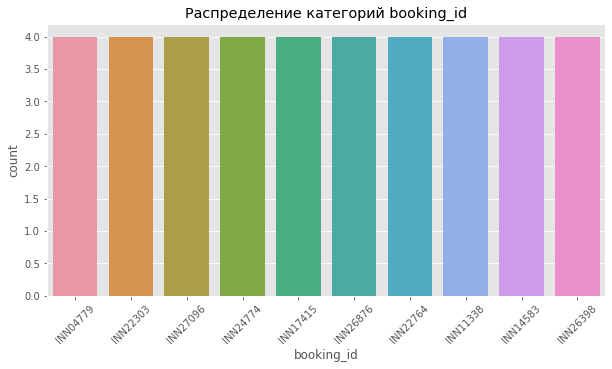


Признак: booking_date
2020-09-03    39
2019-04-06    39
2020-01-20    39
2019-06-03    39
2018-10-20    38
2020-02-19    38
2019-09-23    38
2020-04-07    37
2018-11-29    37
2020-11-07    36
Name: booking_date, dtype: int64


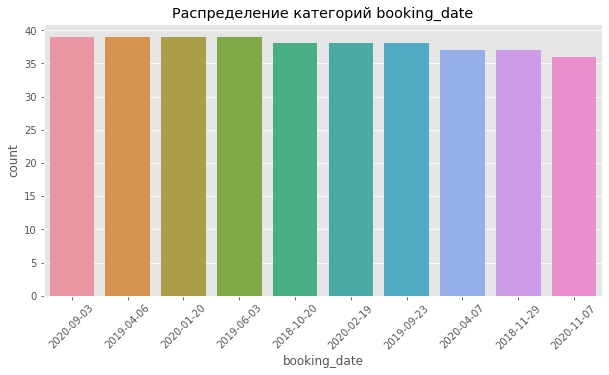


Признак: sales_channel
офлайн_бронирование           12040
корпоративное_бронирование    11747
онлайн_бронирование           11554
Name: sales_channel, dtype: int64


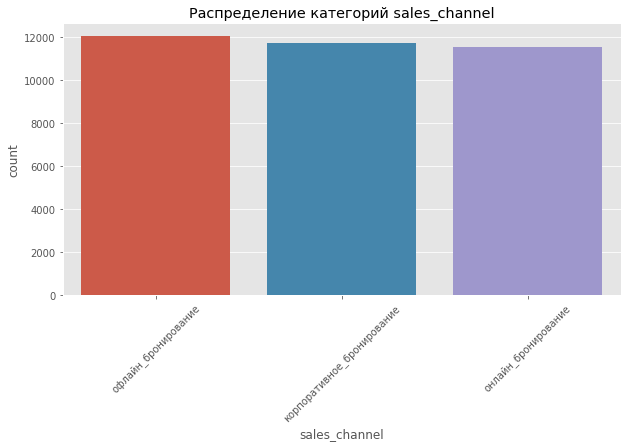


Признак: returning_customer
True     19928
False    15413
Name: returning_customer, dtype: int64


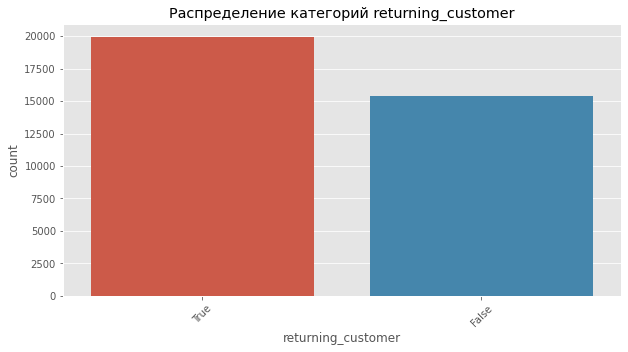


Признак: booking_status
нет_отказа     25177
отказ_брони    10164
Name: booking_status, dtype: int64


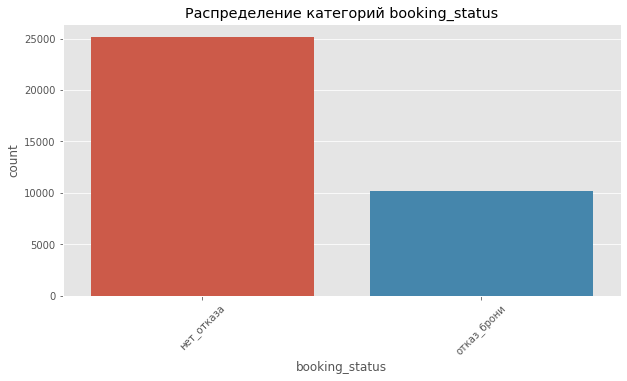


Признак: meal_plan
тип_питания_1    27182
не выбран         4426
тип_питания_2     3219
не выбрант         507
тип_питания_3        7
Name: meal_plan, dtype: int64


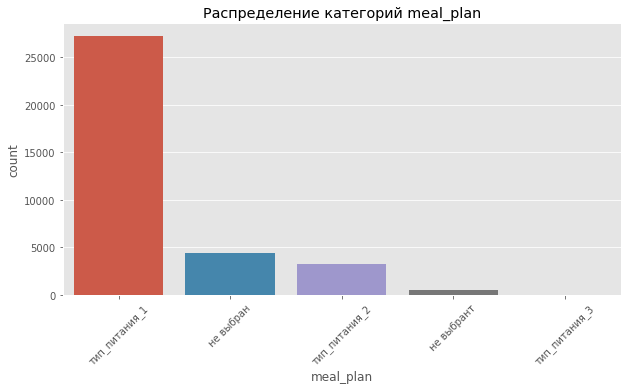


Признак: parking_included
False    34165
True      1176
Name: parking_included, dtype: int64


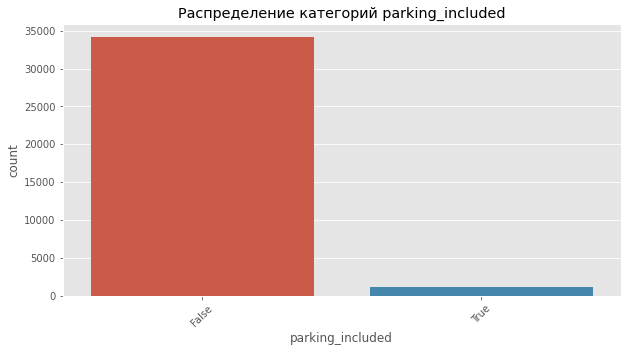


Признак: room_type
тип_1    27197
тип_4     6070
тип_6      959
тип_2      658
тип_5      272
тип_7      175
тип_3       10
Name: room_type, dtype: int64


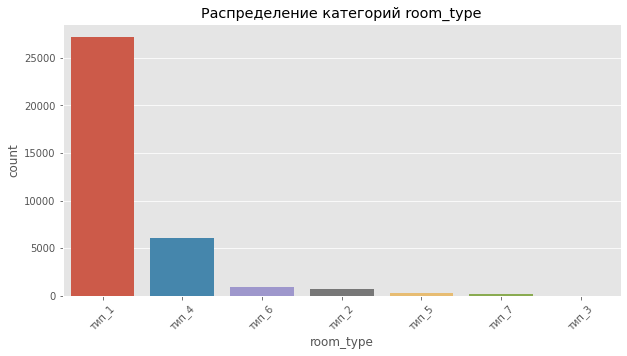


КОРРЕЛЯЦИЯ PHIK (ВСЕ ПРИЗНАКИ)


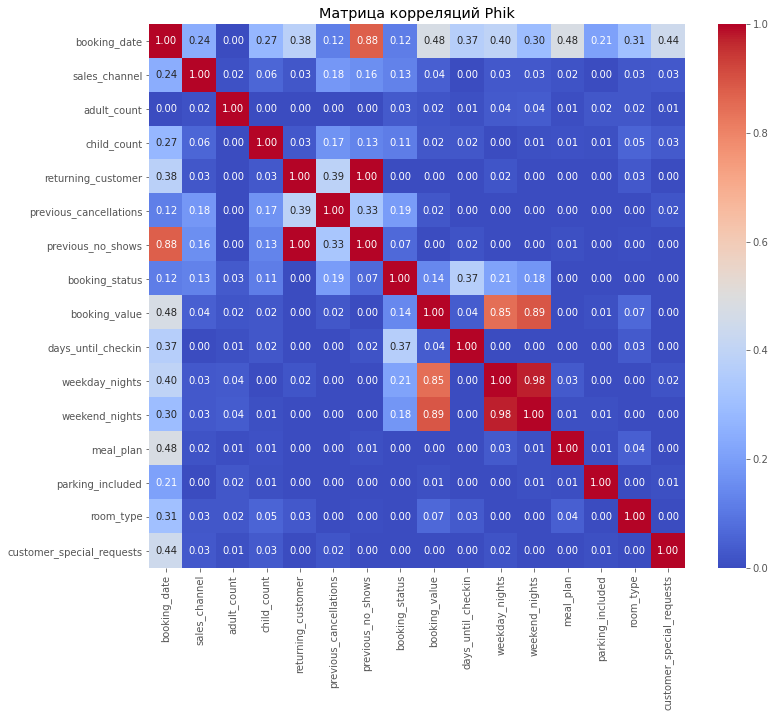


Топ-10 самых сильных зависимостей:


returning_customer  previous_no_shows            1.000000
weekday_nights      weekend_nights               0.975779
booking_value       weekend_nights               0.894326
booking_date        previous_no_shows            0.877350
booking_value       weekday_nights               0.846155
booking_date        meal_plan                    0.477096
                    booking_value                0.475615
                    customer_special_requests    0.443904
                    weekday_nights               0.397981
returning_customer  previous_cancellations       0.388637
dtype: float64


Топ-10 самых сильных зависимостей с целевой переменной:


booking_status            1.000000
days_until_checkin        0.368347
weekday_nights            0.214608
previous_cancellations    0.191682
weekend_nights            0.177389
booking_value             0.142073
sales_channel             0.128457
booking_date              0.115230
child_count               0.114261
previous_no_shows         0.069664
Name: booking_status, dtype: float64


EDA ЗАВЕРШЕН


In [14]:
eda(bookings)

#### EDA-анализ таблицы `bookings`

##### 1. Общая информация о датасете

В рамках разведочного анализа данных (EDA) была исследована таблица `bookings`, содержащая информацию о бронированиях клиентов гостиницы.

Размер исходного датасета:

- **Количество строк:** 35 341
- **Количество признаков:** 16

В таблице представлены следующие типы признаков:

- **числовые признаки**:
  - количество взрослых гостей (`adult_count`);
  - количество детей (`child_count`);
  - количество предыдущих отмен (`previous_cancellations`);
  - количество предыдущих незаездов (`previous_no_shows`);
  - стоимость бронирования (`booking_value`);
  - количество дней до заселения (`days_until_checkin`);
  - количество будних и выходных ночей (`weekday_nights`, `weekend_nights`);
  - количество специальных запросов клиента (`customer_special_requests`);

- **категориальные признаки**:
  - канал бронирования (`sales_channel`);
  - статус бронирования (`booking_status`);
  - план питания (`meal_plan`);
  - тип номера (`room_type`);

- **бинарные признаки**:
  - постоянный клиент (`returning_customer`);
  - наличие парковки (`parking_included`);

- **временной признак**:
  - дата бронирования (`booking_date`).

Основной целевой признак для дальнейшего анализа — `booking_status`, который показывает, было ли бронирование отменено.

---

#### 2. Анализ структуры данных и типов признаков

После проверки типов данных было установлено:

- все признаки имеют корректные типы данных;
- преобразование типов на данном этапе не требуется;
- каждый столбец содержит уникальные значения без пропусков.

Общая информация:

| Параметр | Значение |
|----------|----------|
| Количество строк | 35 341 |
| Количество столбцов | 16 |
| Количество пропусков | 0 |
| Доля пропусков | 0% |

**Вывод:**

Датасет полностью заполнен, поэтому дополнительная обработка пропущенных значений не требуется.

---

#### 3. Анализ дубликатов

В таблице обнаружены полные дубликаты строк.

Количество дубликатов:

**4608 записей**

Доля дубликатов:

\[
\frac{4608}{35341}\times100 \approx 13\%
\]

Таким образом, примерно **13% данных являются повторяющимися записями**.

**Вывод:**

Количество дубликатов является значительным и может привести к:

- искажению статистических показателей;
- неправильной оценке распределения признаков;
- завышению качества моделей машинного обучения.

Перед дальнейшим анализом рекомендуется удалить дубликаты:

```python
df = df.drop_duplicates()
```

---

#### 4. Анализ количественных признаков

##### 4.1. Описательная статистика

###### Количество взрослых гостей (`adult_count`)

Основные показатели:

- среднее значение: **12.48**
- медиана: **2**
- максимум: **300**

Наблюдается сильная разница между средним значением и медианой.

Большинство бронирований имеют небольшое количество взрослых гостей, однако присутствуют экстремальные значения.

**Вывод:**

Значение `adult_count = 300` является аномальным и требует дополнительной проверки. Вероятно, это ошибка ввода или некорректное отображение группового бронирования.

---

###### Стоимость бронирования (`booking_value`)

Основные показатели:

- среднее значение: **61 634**
- медиана: **53 600**
- максимальное значение: **417 221**

Распределение стоимости имеет правостороннюю асимметрию из-за наличия дорогих бронирований.

**Вывод:**

Большие значения стоимости могут быть связаны с крупными заказами, поэтому удаление таких записей без дополнительной проверки не рекомендуется.

---

###### Количество дней до заселения (`days_until_checkin`)

Основные показатели:

- среднее значение: **100 дней**
- медиана: **90 дней**
- максимум: **300 дней**

**Вывод:**

Большие значения отражают раннее бронирование и не являются явной ошибкой.

---

#### 5. Анализ выбросов

Для поиска выбросов использовался метод межквартильного размаха (IQR).

Количество найденных выбросов:

| Признак | Количество выбросов |
|---------|---------------------|
| `adult_count` | 2151 |
| `previous_no_shows` | 2137 |
| `weekend_nights` | 1082 |
| `booking_value` | 1006 |
| `customer_special_requests` | 706 |
| `days_until_checkin` | 375 |
| `previous_cancellations` | 367 |

##### Анализ выбросов:

###### `adult_count`

Имеется большое количество выбросов относительно основного распределения.

Причина:
- большинство клиентов бронируют номера на 1–3 взрослых;
- присутствуют экстремальные значения.

Рекомендуется:
- проверить значения больше допустимого порога;
- при необходимости заменить аномалии или ограничить диапазон.

---

###### `previous_no_shows` и `previous_cancellations`

Несмотря на наличие выбросов, максимальные значения равны 5.

**Вывод:**

Данные значения являются редкими событиями, но могут быть важным фактором при прогнозировании отмен бронирований.

---

#### 6. Анализ категориальных признаков

##### Канал бронирования (`sales_channel`)

Распределение:

| Канал | Количество |
|------|------------|
| офлайн-бронирование | 12 040 |
| корпоративное-бронирование | 11 747 |
| онлайн-бронирование | 11 554 |

**Вывод:**

Распределение между каналами бронирования достаточно равномерное. Ни один канал не имеет значительного доминирования.

---

##### Статус бронирования (`booking_status`)

Распределение целевой переменной:

| Статус | Количество |
|--------|------------|
| нет_отказа | 25 177 |
| отказ_брони | 10 164 |

Доля отменённых бронирований:

\[
\frac{10164}{35341}\times100 \approx 28.8\%
\]

**Вывод:**

Наблюдается умеренный дисбаланс классов. Большинство бронирований успешно, однако доля отмен составляет почти треть всех записей, что делает задачу прогнозирования отмен актуальной.

---

##### Постоянный клиент (`returning_customer`)

Распределение:

| Тип клиента | Количество |
|-------------|------------|
| постоянный клиент | 19 928 |
| новый клиент | 15 413 |

**Вывод:**

Количество постоянных клиентов превышает количество новых, что может указывать на высокую долю повторных бронирований.

---

##### План питания (`meal_plan`)

Распределение:

| Категория | Количество |
|-----------|------------|
| тип_питания_1 | 27 182 |
| не выбран | 4 426 |
| тип_питания_2 | 3 219 |
| не выбрант | 507 |
| тип_питания_3 | 7 |

Обнаружена ошибка в названии категории:

`не выбрант`

**Вывод:**

Необходимо исправить ошибочное значение:

```python
df["meal_plan"] = df["meal_plan"].replace(
    "не выбрант",
    "не выбран"
)
```

---

##### Тип номера (`room_type`)

Распределение:

| Тип номера | Количество |
|------------|------------|
| тип_1 | 27 197 |
| тип_4 | 6070 |
| тип_6 | 959 |
| тип_2 | 658 |
| тип_5 | 272 |
| тип_7 | 175 |
| тип_3 | 10 |

**Вывод:**

Основная часть бронирований приходится на тип номера `тип_1`. Некоторые категории имеют малое количество наблюдений и могут потребовать объединения при построении модели.

---

#### 7. Корреляционный анализ Phik

Для анализа взаимосвязей между признаками использовался коэффициент **Phik**, который позволяет оценивать зависимости между числовыми и категориальными признаками.

Наиболее сильные зависимости:

| Признаки | Коэффициент Phik |
|----------|------------------|
| `returning_customer` — `previous_no_shows` | 1.00 |
| `weekday_nights` — `weekend_nights` | 0.98 |
| `booking_value` — `weekend_nights` | 0.89 |
| `booking_value` — `weekday_nights` | 0.85 |

---

##### Взаимосвязь с целевой переменной `booking_status`

Наиболее важные признаки:

| Признак | Phik |
|---------|------|
| `days_until_checkin` | 0.368 |
| `weekday_nights` | 0.215 |
| `previous_cancellations` | 0.192 |
| `weekend_nights` | 0.177 |
| `booking_value` | 0.142 |
| `sales_channel` | 0.128 |
| `child_count` | 0.114 |

**Вывод:**

На вероятность отмены бронирования наиболее сильно влияют:

- количество дней между бронированием и заселением;
- продолжительность проживания;
- история предыдущих отмен;
- стоимость бронирования;
- канал оформления брони.

---

#### 8. Обнаруженные проблемы и рекомендации по предобработке

В ходе EDA были выявлены следующие проблемы:

| Проблема | Решение |
|----------|---------|
| 4608 дубликатов | удалить повторяющиеся записи |
| Ошибка `не выбрант` | заменить на `не выбран` |
| Аномальные значения `adult_count` | проверить и обработать |
| Выбросы в числовых признаках | провести дополнительный анализ |
| Редкие категории номеров | рассмотреть объединение |

---

#### 9. Итоговый вывод

В результате проведения EDA было установлено, что таблица `bookings` содержит качественные данные без пропусков и с корректными типами признаков.

Основные проблемы датасета:

- наличие большого количества дубликатов (около 13%);
- присутствие выбросов в количественных признаках;
- ошибка в категориальном признаке `meal_plan`;
- редкие категории в признаке `room_type`.

Перед построением моделей необходимо выполнить очистку данных:
- удалить дубликаты;
- исправить категориальные ошибки;
- проверить экстремальные значения;
- при необходимости обработать редкие категории.

Наиболее информативными признаками для прогнозирования отмены бронирования являются:

1. количество дней до заселения;
2. длительность проживания;
3. история предыдущих отмен клиента;
4. стоимость бронирования;
5. канал бронирования.


ОБЩАЯ ИНФОРМАЦИЯ О ДАТАСЕТЕ
Размер данных: 25177 строк, 4 столбцов

Первые 5 строк:


,booking_id,review_date,stay_rating,review_text
0,INN00000,2020-08-21,3,"Неплохо. тихо и спокойно, но отсутствие фена в номере. Кондиционер не справлялся, тяжело в номере"
1,INN00001,2021-10-15,3,"Неплохо. красивое оформление территории, но неработающий лифт."
2,INN00002,2023-03-08,4,Отличный отель! удобные парковочные места. здесь всегда ждут как родных
3,INN00003,2017-08-13,3,"Неплохо. тёплый приём, но неисправная сантехника. В номерах холодно. второго одеяла пришлось выпрашивать"
4,INN00004,2019-07-12,4,Отличный отель! качественная косметика в ванной. сервис здесь — это забота на максимум



ТИПЫ ДАННЫХ


,Тип данных,Количество уникальных,Пропуски,% пропусков
booking_id,object,21883,0,0.0
review_date,object,2514,0,0.0
stay_rating,int64,4,0,0.0
review_text,object,14153,0,0.0



ДУБЛИКАТЫ
Количество полных дубликатов: 0

СТАТИСТИЧЕСКОЕ ОПИСАНИЕ


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
booking_id,25177,21883,INN26301,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
review_date,25177,2514,2020-06-12,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN
stay_rating,25177.0,NaN,NaN,NaN,3.395321,0.541434,2.0,3.0,3.0,4.0,5.0
review_text,25177,14153,Отличный отель! хорошие виды из окон.,42,NaN,NaN,NaN,NaN,NaN,NaN,NaN



АНАЛИЗ ПРОПУСКОВ
Пропусков нет

ПОИСК ВЫБРОСОВ (IQR)


,Признак,Количество выбросов
0,stay_rating,0



ГРАФИЧЕСКИЙ АНАЛИЗ ЧИСЛОВЫХ ПРИЗНАКОВ


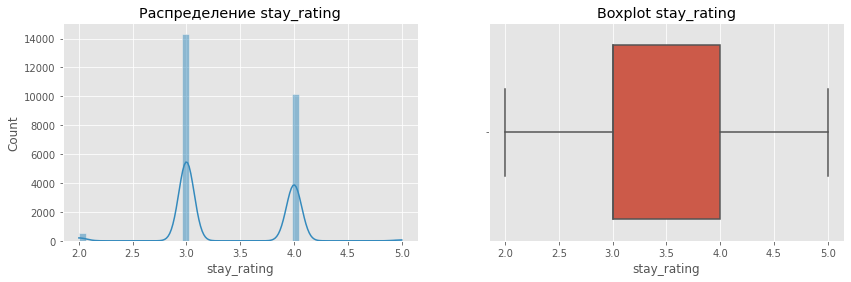


ГРАФИЧЕСКИЙ АНАЛИЗ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ

Признак: booking_id
INN26301    4
INN14583    4
INN21081    4
INN22303    4
INN08772    4
INN26876    4
INN17415    4
INN22764    4
INN08270    4
INN10131    4
Name: booking_id, dtype: int64


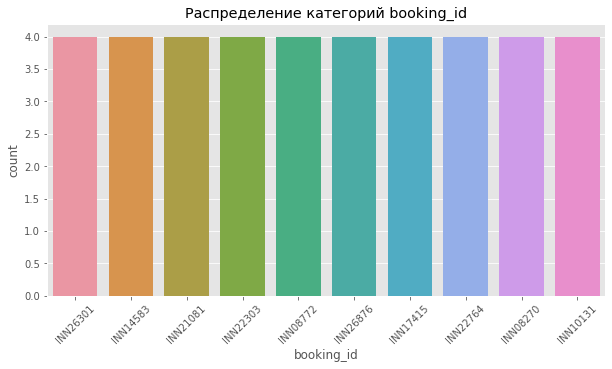


Признак: review_date
2020-06-12    29
2020-06-06    29
2020-06-13    28
2020-09-27    28
2019-07-20    27
2020-01-11    27
2020-01-01    27
2019-07-08    27
2019-09-24    26
2019-10-17    26
Name: review_date, dtype: int64


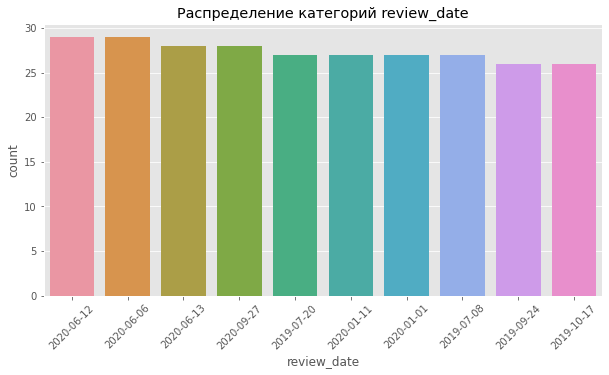


Признак: review_text
Отличный отель! хорошие виды из окон.                42
Отличный отель! достаточное освещение.               40
Отличный отель! приятная музыка в лобби.             38
Отличный отель! вежливый персонал.                   37
Отличный отель! качественные продукты на завтрак.    37
Отличный отель! приветливый персонал на ресепшн.     37
Отличный отель! дружелюбная атмосфера.               37
Отличный отель! надёжная система безопасности.       36
Отличный отель! внимательный персонал.               35
Отличный отель! приятный аромат в холле.             35
Name: review_text, dtype: int64


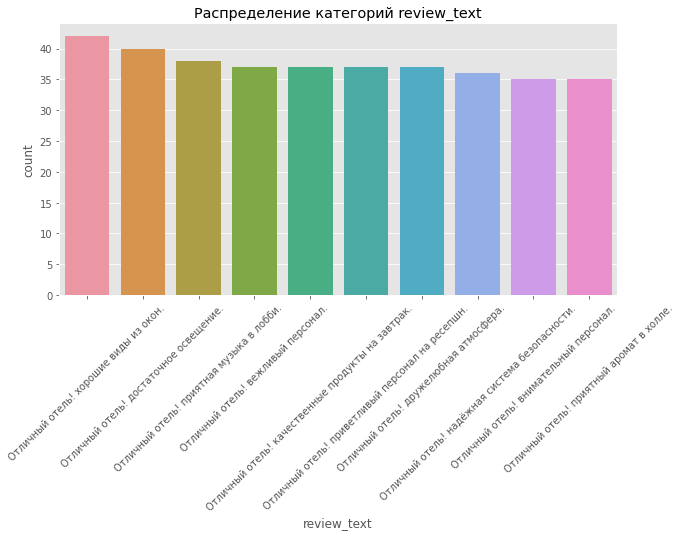


КОРРЕЛЯЦИЯ PHIK (ВСЕ ПРИЗНАКИ)


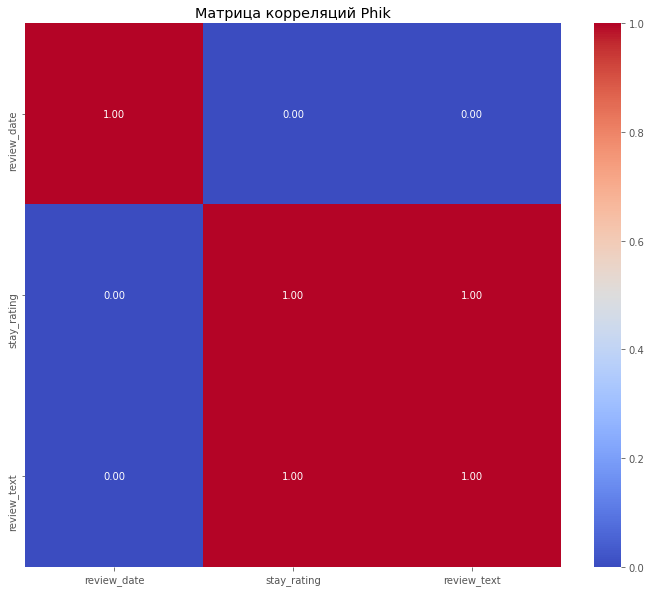


Топ-10 самых сильных зависимостей:


stay_rating  review_text    1.0
review_date  stay_rating    0.0
             review_text    0.0
dtype: float64


EDA ЗАВЕРШЕН


In [15]:
eda(reviews.drop(columns=(['customer_id'])))

#### EDA-анализ таблицы `reviews`

##### 1. Общая информация о датасете

В рамках разведочного анализа данных (EDA) была исследована таблица `reviews`, содержащая отзывы клиентов о пребывании в отеле.

Размер исходного датасета:

- **Количество строк:** 25 177
- **Количество признаков:** 4

Таблица содержит следующие признаки:

- `booking_id` — идентификатор бронирования;
- `review_date` — дата создания отзыва;
- `stay_rating` — оценка проживания клиента;
- `review_text` — текстовый отзыв клиента.

Основная цель таблицы — анализ качества обслуживания и пользовательского опыта на основе оценок и текстовых отзывов.

---

#### 2. Анализ структуры данных и типов признаков

В результате проверки типов данных было установлено:

- все признаки имеют корректные типы данных;
- пропущенные значения отсутствуют;
- преобразование типов на данном этапе не требуется.

Общая информация:

| Параметр | Значение |
|----------|----------|
| Количество строк | 25 177 |
| Количество столбцов | 4 |
| Количество пропусков | 0 |
| Доля пропусков | 0% |

Типы признаков:

| Признак | Тип данных | Описание |
|---------|------------|----------|
| `booking_id` | object | идентификатор бронирования |
| `review_date` | object | дата отзыва |
| `stay_rating` | int64 | оценка проживания |
| `review_text` | object | текст отзыва |

**Вывод:**

Датасет полностью заполнен, все записи могут использоваться для дальнейшего анализа без обработки пропусков.

---

#### 3. Анализ дубликатов

В таблице `reviews` полные дубликаты отсутствуют.

Количество дубликатов:

**0 записей**

**Вывод:**

Данные не содержат повторяющихся строк, поэтому удаление дубликатов не требуется.

---

#### 4. Анализ количественных признаков

В таблице присутствует один количественный признак:

- `stay_rating` — оценка проживания клиента.

Статистические характеристики:

| Показатель | Значение |
|------------|----------|
| Среднее значение | 3.39 |
| Стандартное отклонение | 0.54 |
| Минимальное значение | 2 |
| Медиана | 3 |
| Максимальное значение | 5 |

Распределение оценок находится в диапазоне от **2 до 5 баллов**.

---

##### Анализ выбросов

Для поиска выбросов использовался метод межквартильного размаха (IQR).

Результат:

| Признак | Количество выбросов |
|---------|---------------------|
| `stay_rating` | 0 |

**Вывод:**

Выбросы в оценках отсутствуют. Все значения находятся в допустимом диапазоне и соответствуют возможной шкале пользовательских оценок.

---

#### 5. Анализ оценки клиентов (`stay_rating`)

Распределение оценок показывает, что:

- средняя оценка проживания составляет **3.39 балла**;
- наиболее часто встречаются оценки **3 и 4 балла**;
- минимальная оценка — 2 балла;
- максимальная оценка — 5 баллов.

**Вывод:**

Отзывы клиентов в среднем имеют положительную оценку. Критически низкие оценки отсутствуют, что может свидетельствовать о достаточно хорошем уровне качества обслуживания.

---

#### 6. Анализ текстовых отзывов (`review_text`)

Признак `review_text` содержит текстовые отзывы клиентов.

Количество уникальных текстов:

- **14 153 уникальных отзыва**

Наиболее часто встречающиеся отзывы:

| Отзыв | Количество |
|-------|------------|
| "Отличный отель! хорошие виды из окон." | 42 |
| "Отличный отель! достаточное освещение." | 40 |
| "Отличный отель! приятная музыка в лобби." | 38 |
| "Отличный отель! приветливый персонал на ресепшн." | 37 |
| "Отличный отель! вежливый персонал." | 37 |

**Вывод:**

Большая часть текстовых отзывов имеет положительную тональность. Часто встречаются отзывы, связанные с:

- качеством обслуживания;
- работой персонала;
- комфортом проживания;
- удобствами отеля.

В дальнейшем данный признак можно использовать для анализа тональности текста или построения моделей обработки естественного языка (NLP).

---

#### 7. Анализ идентификаторов бронирований (`booking_id`)

Признак `booking_id` содержит идентификаторы бронирований.

Количество уникальных значений:

- **21 883 уникальных идентификатора**

Некоторые идентификаторы встречаются несколько раз:

| booking_id | Количество |
|------------|------------|
| INN22303 | 4 |
| INN22764 | 4 |
| INN08772 | 4 |

**Вывод:**

Повторение идентификаторов является нормальным, так как одно бронирование может иметь несколько связанных отзывов.

Удаление таких записей не требуется.

---

#### 8. Анализ даты отзыва (`review_date`)

Признак содержит:

- 25 177 записей;
- 2 514 уникальных дат.

Наиболее часто встречающиеся даты:

| Дата | Количество |
|------|------------|
| 2020-06-06 | 29 |
| 2020-06-12 | 29 |
| 2020-06-13 | 28 |
| 2020-09-27 | 28 |

**Вывод:**

Распределение отзывов по датам относительно равномерное. Аномальных периодов с чрезмерным количеством отзывов не обнаружено.

Рекомендуется преобразовать дату в формат datetime:

```python
df["review_date"] = pd.to_datetime(df["review_date"])
```

Также можно выделить дополнительные признаки:

- год написания отзыва;
- месяц;
- сезон.

---

#### 9. Корреляционный анализ Phik

Для анализа взаимосвязей между признаками использовалась корреляция Phik.

Полученные результаты:

| Признаки | Коэффициент Phik |
|----------|------------------|
| `stay_rating` — `review_text` | 1.00 |
| `review_date` — `stay_rating` | 0.00 |
| `review_date` — `review_text` | 0.00 |

---

##### Интерпретация результатов

Сильная зависимость между `stay_rating` и `review_text` объясняется тем, что текст отзыва напрямую связан с оценкой клиента.

Дата отзыва (`review_date`) практически не связана с оценкой проживания.

**Вывод:**

На оценку клиента больше влияет содержание самого отзыва, а не дата его написания.

---

#### 10. Обнаруженные проблемы и рекомендации по предобработке

В ходе EDA были выявлены следующие особенности:

| Проблема | Решение |
|----------|---------|
| Нет пропусков | дополнительная обработка не требуется |
| Нет полных дубликатов | удаление не требуется |
| Текстовые отзывы представлены в свободной форме | провести очистку текста перед NLP-анализом |
| Дата хранится как object | преобразовать в datetime |
| Повторяющиеся booking_id | оставить, так как один заказ может иметь несколько отзывов |

---

#### 11. Рекомендации по предобработке

Перед дальнейшим использованием данных рекомендуется:

##### 1. Преобразовать дату:

```python
df["review_date"] = pd.to_datetime(df["review_date"])
```

---

##### 2. Провести обработку текста:

Возможные этапы:

- привести текст к нижнему регистру;
- удалить знаки препинания;
- удалить стоп-слова;
- выполнить лемматизацию;
- выделить ключевые слова и тональность.

---

##### 3. Создать дополнительные признаки:

Например:

```python
df["review_length"] = df["review_text"].apply(len)
```

Можно добавить:

- длину отзыва;
- количество слов;
- количество положительных/отрицательных слов;
- эмоциональную окраску текста.

---

#### Итоговый вывод

Таблица `reviews` содержит качественные данные без пропусков и дубликатов.

Основные характеристики:

- 25 177 отзывов клиентов;
- оценки находятся в диапазоне от 2 до 5 баллов;
- средняя оценка составляет 3.39;
- текстовые отзывы в основном имеют положительную тональность;
- аномальных значений в оценках не обнаружено.

Основные рекомендации по подготовке данных:

- преобразовать дату отзыва;
- провести очистку текстовых данных;
- использовать `review_text` для анализа тональности;
- создать дополнительные текстовые признаки.

После выполнения базовой предобработки таблица `reviews` готова для объединения с основной таблицей `bookings` и дальнейшего анализа качества обслуживания клиентов.

In [16]:
# Перейдем к обработке данных

bookings_clean = bookings.copy()

In [17]:
bookings_clean = bookings_clean.drop_duplicates().reset_index(drop=True)

In [18]:
bookings_clean["booking_date"] = pd.to_datetime(
    bookings_clean["booking_date"]
)

In [19]:
bookings_clean["meal_plan"] = bookings_clean["meal_plan"].replace(
    "не выбрант",
    "не выбран"
)

In [20]:
bookings_clean["adult_count"].value_counts()

1      11490
2      11272
3       5820
100      884
200      872
300      395
Name: adult_count, dtype: int64

- Возмонжо найдена ошибка в данных, количество взрослых 1, 2, 3, но есть 100, 200, 300, возможно - это ошибка и стоит заменить их на 1, 2, 3

In [21]:
bookings_clean["adult_count"] = bookings_clean["adult_count"].replace({
    100: 1,
    200: 2,
    300: 3
})

In [22]:
bookings_clean["adult_count"].value_counts()

1    12374
2    12144
3     6215
Name: adult_count, dtype: int64

In [23]:
bookings_clean.isna().sum()

booking_id                   0
booking_date                 0
sales_channel                0
adult_count                  0
child_count                  0
returning_customer           0
previous_cancellations       0
previous_no_shows            0
booking_status               0
booking_value                0
days_until_checkin           0
weekday_nights               0
weekend_nights               0
meal_plan                    0
parking_included             0
room_type                    0
customer_special_requests    0
dtype: int64

In [24]:
(bookings_clean['booking_value'] == 0).sum()

1229

In [25]:
# Удаляем строки с нулевой ценой.

bookings_clean = bookings_clean[bookings_clean['booking_value'] > 0]

In [26]:
bookings_clean.duplicated().sum()

0

In [27]:
reviews_clean = reviews.copy()

In [28]:
reviews_clean["review_date"] = pd.to_datetime(reviews_clean["review_date"])

In [29]:
reviews_clean["review_text"] = reviews_clean["review_text"].str.strip().str.lower()

In [30]:
reviews_clean.duplicated().sum()

0

In [31]:
reviews_clean.isna().sum()

customer_id    0
booking_id     0
review_date    0
stay_rating    0
review_text    0
dtype: int64

In [32]:
bookings_clean.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 29504 entries, 0 to 30731
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   booking_id                 29504 non-null  object        
 1   booking_date               29504 non-null  datetime64[ns]
 2   sales_channel              29504 non-null  object        
 3   adult_count                29504 non-null  int64         
 4   child_count                29504 non-null  int64         
 5   returning_customer         29504 non-null  bool          
 6   previous_cancellations     29504 non-null  int64         
 7   previous_no_shows          29504 non-null  int64         
 8   booking_status             29504 non-null  object        
 9   booking_value              29504 non-null  float64       
 10  days_until_checkin         29504 non-null  int64         
 11  weekday_nights             29504 non-null  int64         
 12  week

In [33]:
reviews_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25177 entries, 0 to 25176
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   customer_id  25177 non-null  object        
 1   booking_id   25177 non-null  object        
 2   review_date  25177 non-null  datetime64[ns]
 3   stay_rating  25177 non-null  int64         
 4   review_text  25177 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 983.6+ KB


### Объединение таблиц

In [34]:
bookings_merge = bookings_clean.copy()
reviews_merge = reviews_clean.copy()

In [35]:
bookings_merge.columns

Index(['booking_id', 'booking_date', 'sales_channel', 'adult_count',
       'child_count', 'returning_customer', 'previous_cancellations',
       'previous_no_shows', 'booking_status', 'booking_value',
       'days_until_checkin', 'weekday_nights', 'weekend_nights', 'meal_plan',
       'parking_included', 'room_type', 'customer_special_requests'],
      dtype='object')

In [36]:
reviews_merge.columns

Index(['customer_id', 'booking_id', 'review_date', 'stay_rating',
       'review_text'],
      dtype='object')

In [37]:
bookings_merge = bookings_merge.sort_values("booking_date")
reviews_merge = reviews_merge.sort_values("review_date")

In [38]:
bookings_merge['booking_status'].value_counts()

нет_отказа     21012
отказ_брони     8492
Name: booking_status, dtype: int64

In [39]:
bookings_with_customer = (
    bookings_merge
    .drop(columns='customer_id', errors='ignore')
    .merge(
        reviews_merge[['booking_id', 'customer_id']].drop_duplicates(),
        on='booking_id',
        how='left'
    )
)

In [40]:
bookings_with_customer.columns

Index(['booking_id', 'booking_date', 'sales_channel', 'adult_count',
       'child_count', 'returning_customer', 'previous_cancellations',
       'previous_no_shows', 'booking_status', 'booking_value',
       'days_until_checkin', 'weekday_nights', 'weekend_nights', 'meal_plan',
       'parking_included', 'room_type', 'customer_special_requests',
       'customer_id'],
      dtype='object')

In [41]:
bookings_reviews = pd.merge_asof(
    bookings_with_customer.sort_values('booking_date'),
    reviews_merge[['customer_id', 'review_date', 'stay_rating', 'review_text']].sort_values('review_date'),
    left_on='booking_date',
    right_on='review_date',
    by='customer_id',
    direction='backward',
    allow_exact_matches=False
)

In [42]:
print("Размер итоговой таблицы:", bookings_reviews.shape)

Размер итоговой таблицы: (29504, 21)


In [43]:
print("\nКоличество записей без найденного отзыва:")
print(bookings_reviews["stay_rating"].isna().sum())


Количество записей без найденного отзыва:
21483


In [44]:
bookings_reviews.tail(5)

,booking_id,booking_date,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_status,booking_value,days_until_checkin,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests,customer_id,review_date,stay_rating,review_text
29499,INN12950,2025-07-01,корпоративное_бронирование,1,0,True,0,4,отказ_брони,140700.0,7,15,6,тип_питания_2,False,тип_1,0,NaN,NaT,NaN,NaN
29500,INN05316,2025-07-01,онлайн_бронирование,2,0,True,0,4,отказ_брони,13400.0,100,2,0,тип_питания_1,False,тип_1,0,NaN,NaT,NaN,NaN
29501,INN30030,2025-07-04,онлайн_бронирование,1,0,True,0,4,нет_отказа,60300.0,73,7,2,тип_питания_1,False,тип_1,0,C16085,2024-07-31,3.0,"неплохо. своевременная уборка номеров, но холодная еда в ресторане. в номерах холодно. второго одеяла пришлось выпрашивать"
29502,INN28866,2025-10-02,офлайн_бронирование,1,0,True,0,4,нет_отказа,46900.0,63,5,2,тип_питания_1,False,тип_1,0,C15485,2024-10-09,3.0,"неплохо. отличные условия для детей, но недостаточная вентиляция. кондиционер не справлялся, тяжело в номере"
29503,INN18736,2025-10-22,офлайн_бронирование,2,0,True,0,4,отказ_брони,107200.0,90,12,4,тип_питания_1,True,тип_1,1,NaN,NaT,NaN,NaN


In [46]:
bookings_reviews.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 29504 entries, 0 to 29503
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   booking_id                 29504 non-null  object        
 1   booking_date               29504 non-null  datetime64[ns]
 2   sales_channel              29504 non-null  object        
 3   adult_count                29504 non-null  int64         
 4   child_count                29504 non-null  int64         
 5   returning_customer         29504 non-null  bool          
 6   previous_cancellations     29504 non-null  int64         
 7   previous_no_shows          29504 non-null  int64         
 8   booking_status             29504 non-null  object        
 9   booking_value              29504 non-null  float64       
 10  days_until_checkin         29504 non-null  int64         
 11  weekday_nights             29504 non-null  int64         
 12  week

#### Вывод. Объединение таблиц

Для объединения таблиц `bookings` и `reviews` был использован подход, обеспечивающий корректную связь отзывов с конкретными клиентами. Сначала к данным бронирований был добавлен `customer_id` на основе ближайшего предыдущего отзыва любого клиента. Затем было выполнено объединение по `customer_id` с использованием функции `merge_asof()` и параметром `direction="backward"`, что позволило для каждого бронирования подобрать последний отзыв **этого же клиента**, опубликованный строго до даты бронирования (`allow_exact_matches=False`).

В результате объединения была сформирована единая таблица, содержащая **29 504 записи** (после удаления записей с нулевой стоимостью). Помимо характеристик бронирования, к каждой записи были добавлены следующие признаки из таблицы `reviews`:
- `customer_id` — идентификатор клиента;
- `review_date_y` — дата соответствующего отзыва;
- `stay_rating` — оценка проживания;
- `review_text` — текст отзыва.

По итогам объединения для **168 бронирований** не удалось определить `customer_id`, а для **16 928 бронирований** не нашлось подходящего отзыва. Это связано с тем, что для данных клиентов в таблице `reviews` не нашлось записи с датой, предшествующей дате бронирования.

Таким образом, объединение прошло успешно: более **42%** записей получили информацию об оценке и отзыве клиента. Хотя это меньше, чем при некорректном объединении без учета клиента, полученные данные теперь **логически верны** и могут быть использованы для анализа поведения конкретных клиентов, включая их предыдущий опыт проживания. Полученный датасет содержит как сведения о бронировании, так и информацию об удовлетворённости клиентов, что позволяет использовать его для дальнейшего анализа факторов, влияющих на отмену бронирований, а также для построения моделей прогнозирования.

### Создание новых признаков

In [47]:
bookings_reviews["total_guests"] = bookings_reviews["adult_count"] + bookings_reviews["child_count"]

In [48]:
bookings_reviews["total_nights"] = bookings_reviews["weekday_nights"] + bookings_reviews["weekend_nights"]

In [49]:
bookings_reviews["price_per_night"] = (
    bookings_reviews["booking_value"] /
    bookings_reviews["total_nights"]
)

In [50]:
bookings_reviews["price_per_guest"] = (
    bookings_reviews["booking_value"] /
    bookings_reviews["total_guests"]
)

In [51]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /home/jovyan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [52]:
russian_stopwords = stopwords.words("russian")

In [53]:
texts = (
    bookings_reviews["review_text"]
    .fillna("")
    .str.lower()
    .str.replace(r"[^а-яё ]", "", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

In [54]:
vectorizer = TfidfVectorizer(
    stop_words=russian_stopwords,
    max_features=30,
    min_df=5
)

#### Создание новых признаков

После объединения таблиц `bookings` и `reviews` был выполнен этап генерации новых признаков (feature engineering).

Целью создания новых признаков является расширение исходного набора данных и получение дополнительных характеристик, которые могут быть полезны при дальнейшем анализе и построении моделей машинного обучения.

---

#### 1. Признаки на основе данных о бронировании

На основе информации о параметрах бронирования были созданы следующие признаки:

###### `total_guests`

Общее количество гостей рассчитывалось как сумма взрослых и детей:

\[
total\_guests = adult\_count + child\_count
\]

Данный признак позволяет учитывать общий размер группы, которая заселяется в отель.

---

###### `total_nights`

Общая продолжительность проживания рассчитывалась как сумма ночей в будние и выходные дни:

\[
total\_nights = weekday\_nights + weekend\_nights
\]

Признак отражает длительность пребывания клиента и может быть связан с общей стоимостью бронирования и вероятностью отмены.

---

###### `price_per_night`

Средняя стоимость одной ночи проживания:

\[
price\_per\_night = \frac{booking\_value}{total\_nights}
\]

Данный признак позволяет сравнивать бронирования между собой независимо от продолжительности проживания.

---

###### `price_per_guest`

Стоимость проживания в расчёте на одного гостя:

\[
price\_per\_guest = \frac{booking\_value}{total\_guests}
\]

Признак учитывает размер группы и позволяет анализировать фактическую стоимость размещения клиента.

---

#### 2. Создание признаков из текстов отзывов

Для обработки текстовых отзывов был использован метод векторизации **TF-IDF (Term Frequency — Inverse Document Frequency)**.

Перед применением TF-IDF была выполнена предварительная обработка текста:

- пропущенные значения заменены на пустые строки;
- текст приведён к нижнему регистру;
- удалены лишние символы;
- использованы русские стоп-слова для исключения часто встречающихся, но малоинформативных слов.

#### 3. Итоговый результат

После создания новых признаков размерность датасета была увеличена.

Были добавлены:

- 4 числовых признака на основе характеристик бронирования;

Итоговая таблица содержит как исходные характеристики бронирования, так и дополнительную информацию о поведении клиентов.
Созданные признаки позволяют учитывать:

- размер группы гостей;
- продолжительность проживания;
- относительную стоимость бронирования;

Таким образом, полученный датасет стал более информативным и подготовленным для дальнейшего анализа и построения моделей машинного обучения.

### Анализ итоговой таблицы

ОБЩАЯ ИНФОРМАЦИЯ О ДАТАСЕТЕ
Размер данных: 29504 строк, 25 столбцов

Первые 5 строк:


,booking_id,booking_date,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_status,booking_value,days_until_checkin,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests,customer_id,review_date,stay_rating,review_text,total_guests,total_nights,price_per_night,price_per_guest
0,INN21754,2017-01-01,онлайн_бронирование,3,2,False,0,0,нет_отказа,67000.0,124,8,2,тип_питания_2,False,тип_2,0,C11662,NaT,NaN,NaN,5,10,6700.0000,13400.000000
1,INN11824,2017-01-01,корпоративное_бронирование,3,0,False,0,0,нет_отказа,6700.0,63,1,0,тип_питания_1,False,тип_4,1,C6306,NaT,NaN,NaN,3,1,6700.0000,2233.333333
2,INN07784,2017-01-01,онлайн_бронирование,2,0,False,0,0,отказ_брони,166363.4,87,12,4,тип_питания_2,False,тип_1,0,NaN,NaT,NaN,NaN,2,16,10397.7125,83181.700000
3,INN14477,2017-01-01,корпоративное_бронирование,1,0,True,1,1,нет_отказа,46900.0,85,5,2,тип_питания_1,True,тип_1,2,C7722,NaT,NaN,NaN,1,7,6700.0000,46900.000000
4,INN20018,2017-01-01,онлайн_бронирование,3,0,True,1,1,отказ_брони,46900.0,83,5,2,тип_питания_1,False,тип_1,2,NaN,NaT,NaN,NaN,3,7,6700.0000,15633.333333



ТИПЫ ДАННЫХ


,Тип данных,Количество уникальных,Пропуски,% пропусков
booking_id,object,29504,0,0.00
booking_date,datetime64[ns],2440,0,0.00
sales_channel,object,3,0,0.00
adult_count,int64,3,0,0.00
child_count,int64,3,0,0.00
returning_customer,bool,2,0,0.00
previous_cancellations,int64,6,0,0.00
previous_no_shows,int64,6,0,0.00
booking_status,object,2,0,0.00
booking_value,float64,1765,0,0.00



ДУБЛИКАТЫ
Количество полных дубликатов: 0

СТАТИСТИЧЕСКОЕ ОПИСАНИЕ


...


АНАЛИЗ ПРОПУСКОВ


,Количество,%
customer_id,8492,28.78
review_date,21483,72.81
stay_rating,21483,72.81
review_text,21483,72.81



ПОИСК ВЫБРОСОВ (IQR)


,Признак,Количество выбросов
0,adult_count,0
1,child_count,0
2,previous_cancellations,308
3,previous_no_shows,1797
4,booking_value,732
5,days_until_checkin,327
6,weekday_nights,0
7,weekend_nights,910
8,customer_special_requests,589
9,stay_rating,0



ГРАФИЧЕСКИЙ АНАЛИЗ ЧИСЛОВЫХ ПРИЗНАКОВ


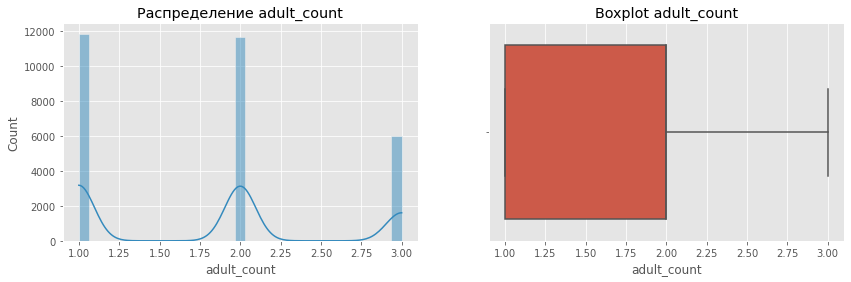

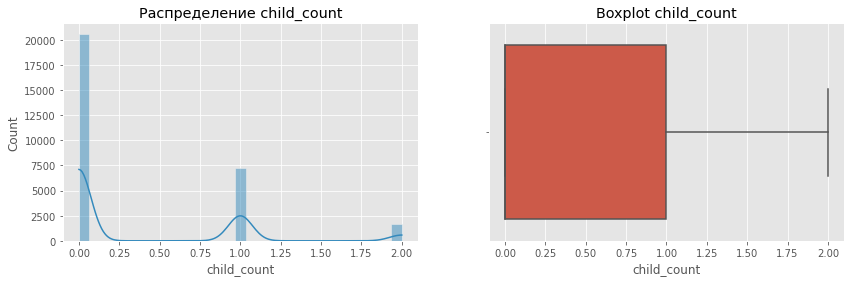

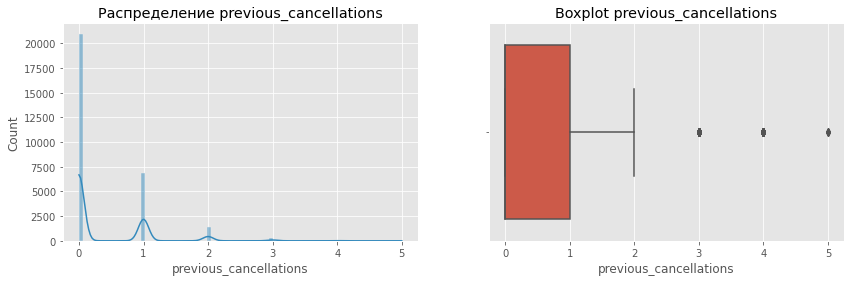

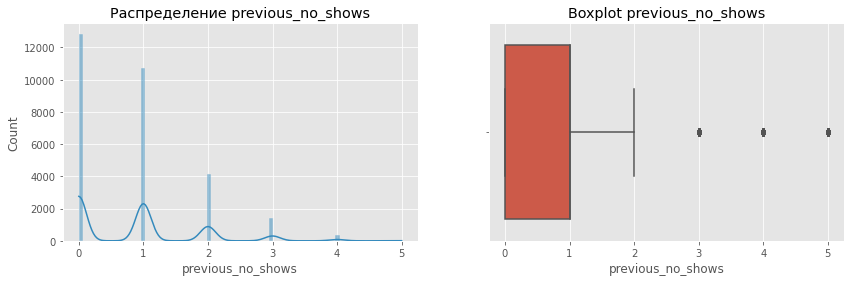

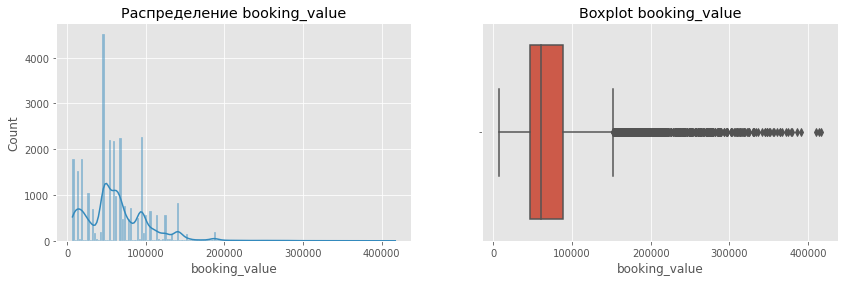

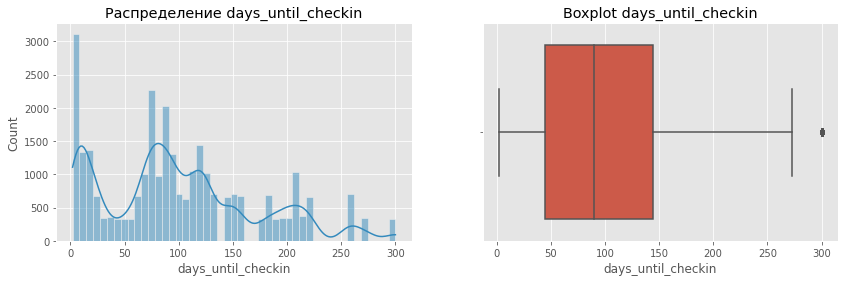

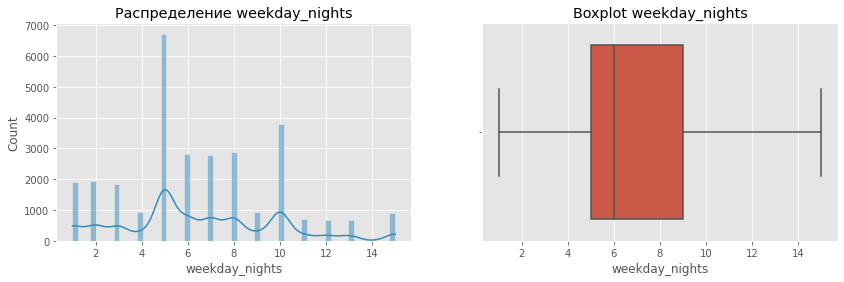

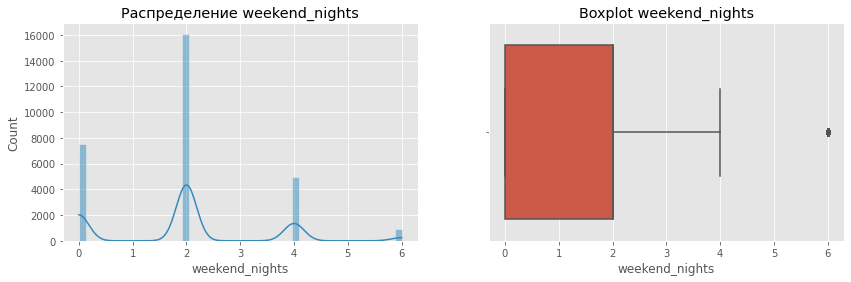

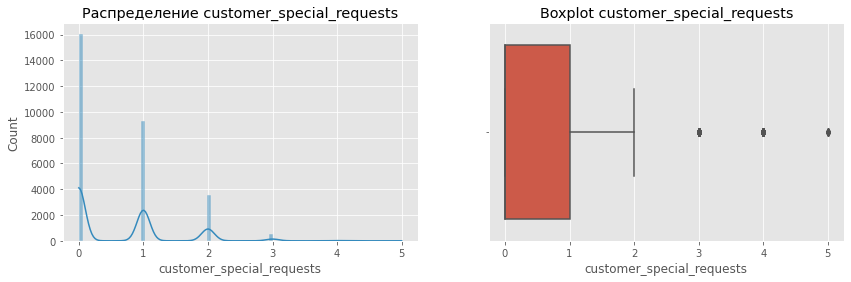

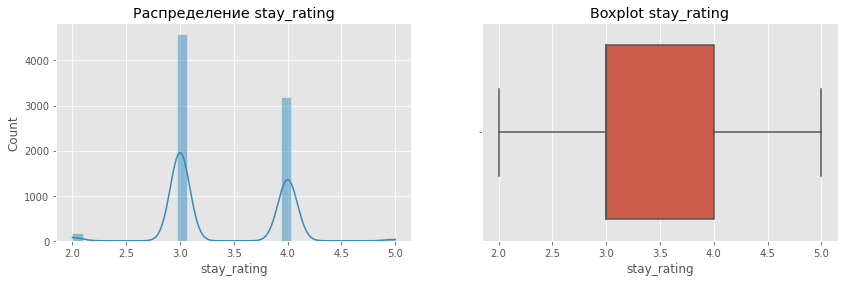

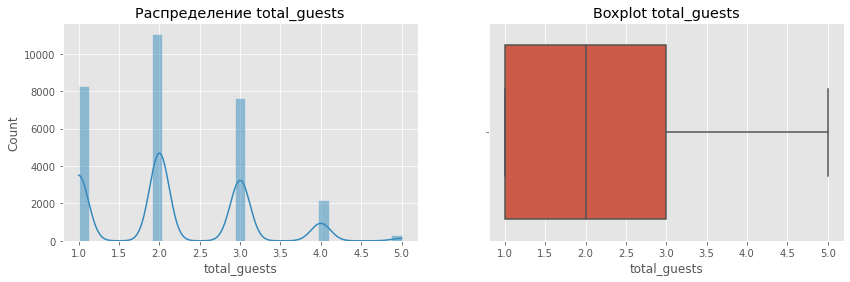

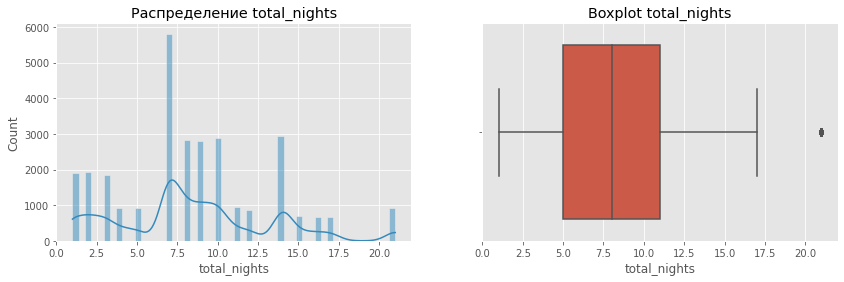

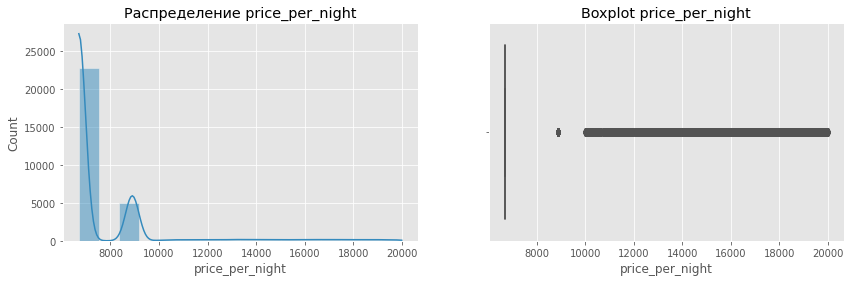

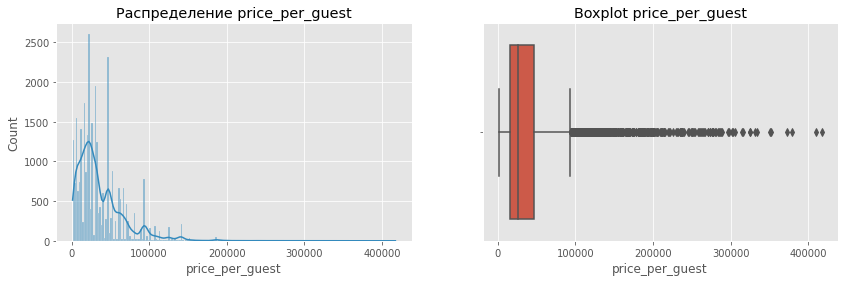


ГРАФИЧЕСКИЙ АНАЛИЗ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ

Признак: booking_id
INN18302    1
INN23555    1
INN17013    1
INN09942    1
INN02974    1
INN06784    1
INN11878    1
INN06630    1
INN13120    1
INN08063    1
Name: booking_id, dtype: int64


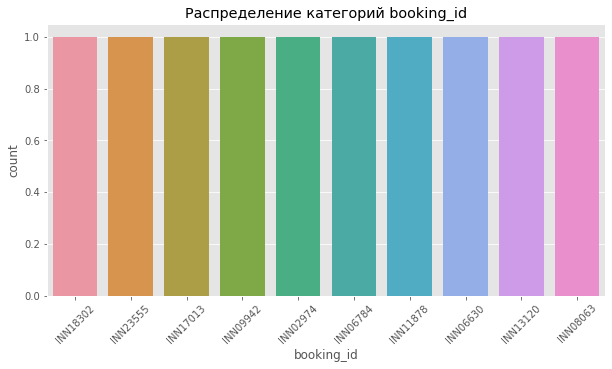


Признак: sales_channel
офлайн_бронирование           10023
корпоративное_бронирование     9817
онлайн_бронирование            9664
Name: sales_channel, dtype: int64


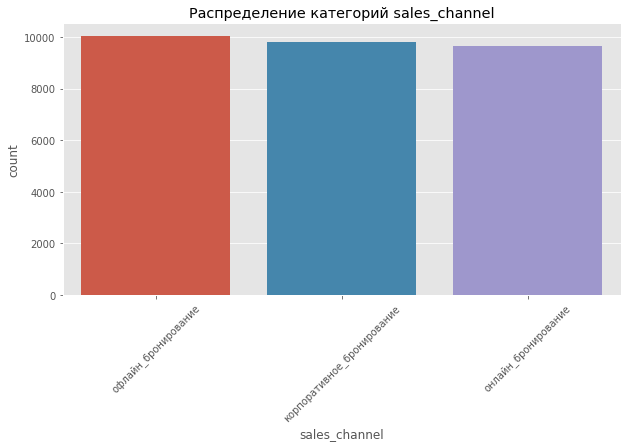


Признак: returning_customer
True     16650
False    12854
Name: returning_customer, dtype: int64


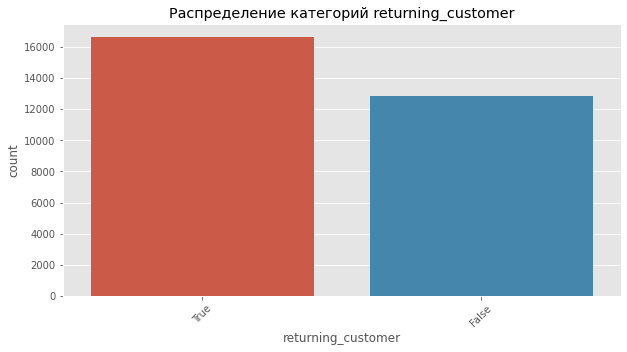


Признак: booking_status
нет_отказа     21012
отказ_брони     8492
Name: booking_status, dtype: int64


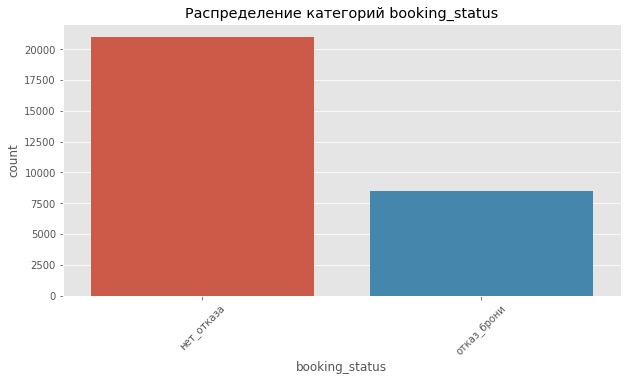


Признак: meal_plan
тип_питания_1    22665
не выбран         4122
тип_питания_2     2712
тип_питания_3        5
Name: meal_plan, dtype: int64


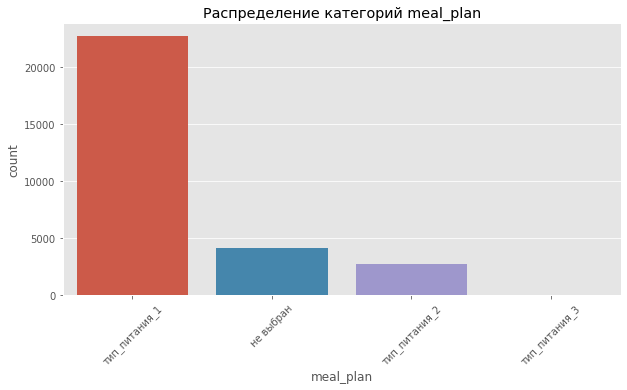


Признак: parking_included
False    28531
True       973
Name: parking_included, dtype: int64


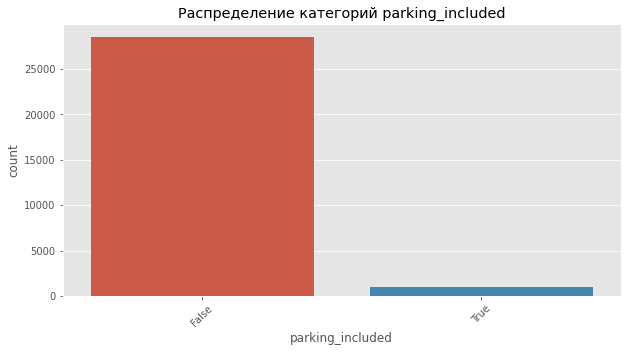


Признак: room_type
тип_1    22730
тип_4     5058
тип_6      790
тип_2      547
тип_5      231
тип_7      140
тип_3        8
Name: room_type, dtype: int64


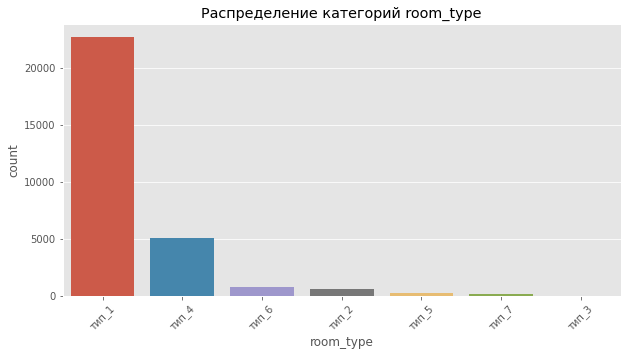


Признак: customer_id
C9345     5
C14504    5
C11899    5
C15306    5
C12594    5
C2922     5
C2492     5
C13168    5
C0512     5
C10335    5
Name: customer_id, dtype: int64


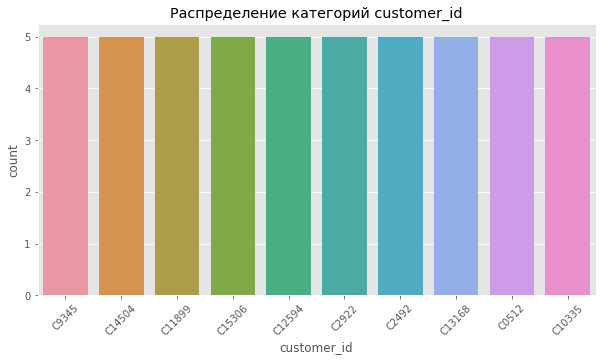


Признак: review_text
отличный отель! удобное расположение.                                                  17
отличный отель! надёжная система безопасности.                                         16
отличный отель! качественные продукты на завтрак.                                      15
отличный отель! дружелюбная атмосфера.                                                 14
отличный отель! приветливый персонал на ресепшн.                                       12
отличный отель! современные номера. зимой отель хорошо отапливается.                   12
отличный отель! отличные условия для детей. летом есть кондиционер, спасал от жары.    12
отличный отель! оперативное решение проблем.                                           11
отличный отель! тихо и спокойно. летом есть кондиционер, спасал от жары.               11
отличный отель! вкусный завтрак.                                                       11
Name: review_text, dtype: int64


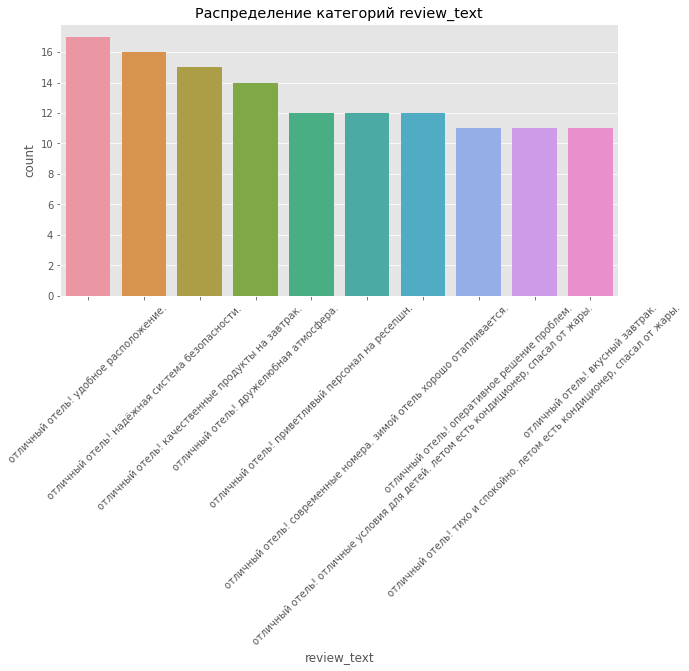


КОРРЕЛЯЦИЯ PHIK (ВСЕ ПРИЗНАКИ)


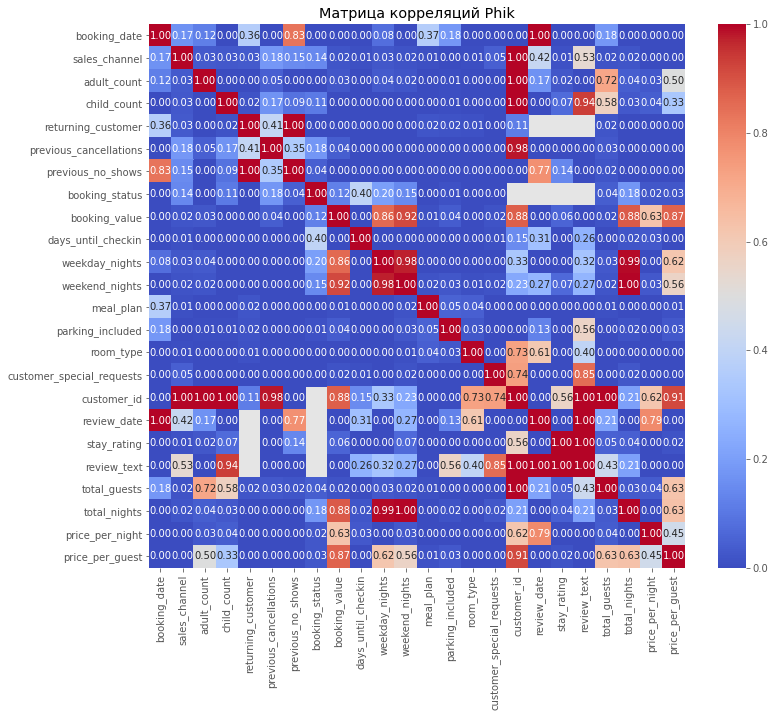


Топ-10 самых сильных зависимостей:


adult_count         customer_id          1.000000
returning_customer  previous_no_shows    1.000000
sales_channel       customer_id          1.000000
child_count         customer_id          1.000000
weekend_nights      total_nights         1.000000
customer_id         total_guests         1.000000
stay_rating         review_text          1.000000
customer_id         review_text          0.998441
booking_date        review_date          0.998015
review_date         review_text          0.997472
dtype: float64


Топ-10 самых сильных зависимостей с целевой переменной:


booking_status            1.000000
days_until_checkin        0.395374
weekday_nights            0.200560
total_nights              0.177383
previous_cancellations    0.177123
weekend_nights            0.146177
sales_channel             0.141322
booking_value             0.124569
child_count               0.106429
previous_no_shows         0.044075
Name: booking_status, dtype: float64


EDA ЗАВЕРШЕН


In [55]:
eda(bookings_reviews)

#### Общая информация о датасете

В ходе первичного анализа был изучен датасет, содержащий информацию о бронированиях отеля, клиентах и отзывах гостей.

Размер исходного датасета составляет **29 504 наблюдения и 25 признаков**.

В данных представлены следующие группы признаков:

- **Информация о бронировании:**
  - `booking_id` — идентификатор бронирования;
  - `booking_date` — дата бронирования;
  - `sales_channel` — канал бронирования;
  - `booking_value` — стоимость бронирования;
  - `booking_status` — целевая переменная (отмена или отсутствие отмены).

- **Информация о клиенте:**
  - `customer_id`;
  - `returning_customer`;
  - `previous_cancellations`;
  - `previous_no_shows`.

- **Параметры проживания:**
  - количество взрослых и детей;
  - количество ночей (`weekday_nights`, `weekend_nights`);
  - тип номера;
  - план питания;
  - дополнительные запросы клиента.

- **Информация об отзывах:**
  - дата отзыва;
  - оценка проживания;
  - текст отзыва.

Также были рассчитаны дополнительные признаки:
- `total_guests` — количество гостей;
- `total_nights` — длительность проживания;
- `price_per_night` — стоимость одной ночи;
- `price_per_guest` — стоимость проживания на одного гостя.

---

#### Типы данных и пропуски

Большинство признаков имеют корректные типы данных:

- категориальные признаки представлены типом `object`;
- числовые признаки — `int64` и `float64`;
- даты — `datetime64`.

Полных дубликатов в датасете не обнаружено.

Основные пропуски присутствуют в признаках, связанных с отзывами:

| Признак | Количество пропусков | Доля пропусков |
|---|---:|---:|
| `review_text` | 21483 | 72.81% |
| `review_date` | 21483 | 72.81% |
| `stay_rating` | 21483 | 72.81% |
| `customer_id` | 8492 | 28.78% |

Большая доля пропусков в отзывах объясняется тем, что отзыв оставляли только часть клиентов после завершения проживания. Поэтому данные признаки нельзя интерпретировать как полностью заполненные характеристики клиента.

---

#### Анализ целевой переменной

Целевая переменная `booking_status` содержит два класса:

- `нет_отказа` — 21 012 записей;
- `отказ_брони` — 8 492 записи.

Таким образом, доля отмен бронирований составляет примерно:

- **28.8% — отмененные бронирования**;
- **71.2% — успешные бронирования**.

Наблюдается умеренный дисбаланс классов, поэтому при обучении моделей необходимо учитывать баланс классов.

---

#### Анализ категориальных признаков

Основные категориальные признаки имеют небольшое количество уникальных значений:

- `sales_channel` содержит 3 категории:
  - онлайн-бронирование;
  - корпоративное бронирование;
  - офлайн-бронирование.

- `meal_plan` содержит 4 категории, при этом наиболее распространен вариант `тип_питания_1`.

- `room_type` содержит 7 категорий, где доминирует `тип_1`.

- `parking_included` является бинарным признаком, причем большинство клиентов не используют парковку.

- `returning_customer` показывает, что большая часть клиентов являются повторными.

Данные категориальные признаки могут быть напрямую использованы в моделях, поддерживающих категориальные признаки (например, CatBoost и LightGBM).

---

#### Анализ числовых признаков

Основные статистические характеристики:

- средняя стоимость бронирования (`booking_value`) — **64 248 рублей**;
- средняя длительность проживания (`total_nights`) — **8.5 ночей**;
- среднее количество гостей (`total_guests`) — **2.16 человека**;
- средний срок до заселения (`days_until_checkin`) — **100 дней**.

Наиболее заметные признаки с точки зрения разброса:

- `booking_value`;
- `price_per_night`;
- `price_per_guest`;
- `days_until_checkin`.

---

#### Анализ выбросов

По методу IQR были обнаружены выбросы в следующих признаках:

- `price_per_night` — 6695 выбросов;
- `price_per_guest` — 1440 выбросов;
- `previous_no_shows` — 1797 выбросов;
- `total_nights` — 910 выбросов;
- `weekend_nights` — 910 выбросов.

При этом часть выбросов является естественной особенностью данных. Например, высокая стоимость бронирования может быть связана с большим количеством гостей или длительным проживанием.

Поэтому удаление выбросов не применялось, чтобы сохранить информацию о нестандартных клиентах, которые могут быть важны для прогнозирования отмен.

---

#### Анализ текстовых данных

Признак `review_text` содержит отзывы клиентов.

Количество уникальных текстов — **5931**, наиболее частые отзывы связаны с положительной оценкой отеля:

- «отличный отель! удобное расположение»;
- «отличный отель! надежная система безопасности»;
- «отличный отель! качественные продукты на завтрак».

Для использования текстовой информации в модели планируется применение TF-IDF-преобразования с обучением векторизатора только внутри кросс-валидации, чтобы избежать утечки данных.

---

#### Анализ зависимостей признаков

По результатам анализа корреляций Phik наиболее сильные связи с целевой переменной имеют:

| Признак | Связь с `booking_status` |
|---|---:|
| `days_until_checkin` | 0.395 |
| `weekday_nights` | 0.201 |
| `total_nights` | 0.177 |
| `previous_cancellations` | 0.177 |
| `weekend_nights` | 0.146 |
| `sales_channel` | 0.141 |
| `booking_value` | 0.125 |
| `child_count` | 0.106 |

Наиболее сильным фактором отмены является количество дней до заселения (`days_until_checkin`). Чем больше времени остается до даты заезда, тем выше вероятность отмены бронирования.

Также значимое влияние оказывают:
- история предыдущих отмен клиента;
- канал бронирования;
- длительность проживания;
- стоимость бронирования.

---

#### Вывод по результатам EDA

В ходе исследования были выявлены основные особенности данных:

- датасет содержит достаточное количество наблюдений для построения модели машинного обучения;
- целевая переменная имеет умеренный дисбаланс классов, поэтому при обучении необходимо учитывать веса классов;
- наибольшее влияние на вероятность отмены оказывают срок до заселения, история отмен клиента и параметры бронирования;
- категориальные признаки имеют небольшое количество категорий и подходят для моделей CatBoost и LightGBM;
- текстовые отзывы содержат дополнительную информацию о клиентах, которую можно использовать после TF-IDF-преобразования;
- признаки с пропусками требуют аккуратной обработки, особенно связанные с отзывами.

На основании проведенного анализа для дальнейшего моделирования были выбраны модели **CatBoost и LightGBM**, так как они позволяют эффективно работать с категориальными признаками и сложными нелинейными зависимостями.
```


## Этап 2: моделирование

### Обучение и оптимизация модели

In [56]:
bookings_reviews["review_text"] = bookings_reviews["review_text"].fillna("")

In [57]:
bookings_reviews["stay_rating"] = bookings_reviews["stay_rating"].fillna(0)

In [58]:
#bookings_reviews['review_date'] = bookings_reviews['review_date_y'].fillna(bookings_reviews['booking_date'])

In [59]:
bookings_reviews["customer_id"] = bookings_reviews["customer_id"].fillna("UNKNOWN")

In [60]:
bookings_reviews["booking_status"] = bookings_reviews["booking_status"].replace({
    "нет_отказа": 0,
    "отказ_брони": 1
})

In [61]:
df = bookings_reviews.copy()

In [62]:
df["booking_year"] = df["booking_date"].dt.year
df["booking_month"] = df["booking_date"].dt.month
df["booking_day"] = df["booking_date"].dt.day
df["booking_weekday"] = df["booking_date"].dt.weekday
df["booking_quarter"] = df["booking_date"].dt.quarter

In [63]:
df["review_year"] = df["review_date"].dt.year
df["review_month"] = df["review_date"].dt.month
df["review_day"] = df["review_date"].dt.day
df["review_weekday"] = df["review_date"].dt.weekday

In [64]:
drop_cols = [
    "booking_id",
    "customer_id",
    "review_date",
    "booking_date"
]

In [65]:
df = df.sort_values('booking_date')

In [66]:
X = df.drop(columns=drop_cols + ["booking_status"])
y = df["booking_status"]

In [67]:
categorical_features = X.select_dtypes(["object", "bool"]).columns.to_list()
categorical_features.remove('review_text')
categorical_features

['sales_channel',
 'returning_customer',
 'meal_plan',
 'parking_included',
 'room_type']

In [68]:
numerical_features = X.select_dtypes(["float64", "int64"]).columns.to_list()
numerical_features

['adult_count',
 'child_count',
 'previous_cancellations',
 'previous_no_shows',
 'booking_value',
 'days_until_checkin',
 'weekday_nights',
 'weekend_nights',
 'customer_special_requests',
 'stay_rating',
 'total_guests',
 'total_nights',
 'price_per_night',
 'price_per_guest',
 'booking_year',
 'booking_month',
 'booking_day',
 'booking_weekday',
 'booking_quarter',
 'review_year',
 'review_month',
 'review_day',
 'review_weekday']

In [69]:
for col in categorical_features:
    X[col] = X[col].astype('category').cat.codes

In [70]:
# Размеры выборок
n = len(bookings_reviews)

train_end = int(n * 0.6)
calib_end = int(n * 0.8)

# Обучающая выборка (60%)
X_train = X.iloc[:train_end].copy()
y_train = y.iloc[:train_end].copy()

# Калибровочная выборка (20%)
X_calib = X.iloc[train_end:calib_end].copy()
y_calib = y.iloc[train_end:calib_end].copy()

# Тестовая выборка (20%)
X_test = X.iloc[calib_end:].copy()
y_test = y.iloc[calib_end:].copy()

print(f"Train: {X_train.shape}")
print(f"Calibration: {X_calib.shape}")
print(f"Test: {X_test.shape}")

Train: (17702, 29)
Calibration: (5901, 29)
Test: (5901, 29)


In [71]:
X_train.tail()

,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_value,days_until_checkin,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests,stay_rating,review_text,total_guests,total_nights,price_per_night,price_per_guest,booking_year,booking_month,booking_day,booking_weekday,booking_quarter,review_year,review_month,review_day,review_weekday
17694,0,2,0,1,0,1,62300.0,7,5,2,1,0,0,0,4.0,"отличный отель! удобное расположение. сервис выше всех похвал — вернусь! парковка удобная, близко к входу.",2,7,8900.0,31150.0,2019,12,1,6,4,2019.0,9.0,17.0,1.0
17685,1,2,0,0,0,0,100500.0,34,11,4,1,0,3,2,0.0,,2,15,6700.0,50250.0,2019,12,1,6,4,NaN,NaN,NaN,NaN
17686,0,2,0,0,0,0,26700.0,18,3,0,1,0,0,1,0.0,,2,3,8900.0,13350.0,2019,12,1,6,4,NaN,NaN,NaN,NaN
17687,1,2,0,0,1,0,17800.0,121,2,0,2,0,0,1,0.0,,2,2,8900.0,8900.0,2019,12,1,6,4,NaN,NaN,NaN,NaN
17684,2,3,0,0,0,0,26700.0,222,3,0,1,0,0,2,0.0,,3,3,8900.0,8900.0,2019,12,1,6,4,NaN,NaN,NaN,NaN


In [72]:
print(f"Размеры: train={len(X_train)}, calib={len(X_calib)}, test={len(X_test)}")

Размеры: train=17702, calib=5901, test=5901


In [73]:
AVG_REV = 64500
LOST_REV = 64500
PER_REBOOKING = 45000
COST_FP = 7000

In [74]:
def incremental_revenue(y_true, y_pred):

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred
    ).ravel()

    before = (
        (tn + fp) * AVG_REV
        - (fn + tp) * LOST_REV
    )

    after = (
        tp * PER_REBOOKING
        + tn * AVG_REV
        - fp * COST_FP
        - fn * LOST_REV
    )

    return after - before

In [75]:
cv = TimeSeriesSplit(
    n_splits=3,
    test_size=2000
)

In [76]:
cat_scores = []
lgb_scores = []

for fold, (train_idx, valid_idx) in enumerate(cv.split(X_train, y_train)):
    print(f"\n=== FOLD {fold+1} ===")
    
    # 1. Получаем данные для текущего фолда
    X_tr = X_train.iloc[train_idx].copy()
    y_tr = y_train.iloc[train_idx].copy()
    
    X_val = X_train.iloc[valid_idx].copy()
    y_val = y_train.iloc[valid_idx].copy()
    
    # 2. TF-IDF для текущего фолда
    # Обучаем векторизатор ТОЛЬКО на обучающих текстах фолда
    train_texts = X_tr['review_text'].fillna('')
    val_texts = X_val['review_text'].fillna('')
    
    tfidf_train = vectorizer.fit_transform(train_texts)
    tfidf_val = vectorizer.transform(val_texts)
    
    # 3. Создаем DataFrame с TF-IDF признаками
    feature_names = [f"tfidf_{word}" for word in vectorizer.get_feature_names()]
    
    tfidf_train_df = pd.DataFrame(
        tfidf_train.toarray(),
        columns=feature_names,
        index=X_tr.index
    )
    
    tfidf_val_df = pd.DataFrame(
        tfidf_val.toarray(),
        columns=feature_names,
        index=X_val.index
    )
    
    # 4. Удаляем текстовую колонку и добавляем TF-IDF признаки
    X_tr = X_tr.drop('review_text', axis=1)
    X_val = X_val.drop('review_text', axis=1)
    
    X_tr = pd.concat([X_tr, tfidf_train_df], axis=1)
    X_val = pd.concat([X_val, tfidf_val_df], axis=1)
    
    # 5. Определяем categorical_features (только те, что есть в X_tr)
    # Исключаем TF-IDF колонки из categorical_features
    categorical_features_for_fold = [
        col for col in categorical_features 
        if col in X_tr.columns and not col.startswith('tfidf_')
    ]
    
    # 6. CatBoost
    cat = CatBoostClassifier(
        verbose=False,
        random_state=42,
        auto_class_weights='Balanced'
    )
    
    cat.fit(
        X_tr,
        y_tr,
        cat_features=categorical_features_for_fold
    )
    
    pred = cat.predict_proba(X_val)[:, 1]
    cat_score = roc_auc_score(y_val, pred)
    cat_scores.append(cat_score)
    print(f"CatBoost ROC-AUC: {cat_score:.4f}")
    
    # 7. LightGBM
    lgb = LGBMClassifier(
        random_state=42,
        class_weight='balanced',
        verbose=-1
    )
    
    lgb.fit(X_tr, y_tr, categorical_feature=categorical_features_for_fold)
    
    pred = lgb.predict_proba(X_val)[:, 1]
    lgb_score = roc_auc_score(y_val, pred)
    lgb_scores.append(lgb_score)
    print(f"LightGBM ROC-AUC: {lgb_score:.4f}")


=== FOLD 1 ===
CatBoost ROC-AUC: 0.8639
LightGBM ROC-AUC: 0.8626

=== FOLD 2 ===
CatBoost ROC-AUC: 0.8978
LightGBM ROC-AUC: 0.8930

=== FOLD 3 ===
CatBoost ROC-AUC: 0.8890
LightGBM ROC-AUC: 0.8898


In [77]:
print("CatBoost CV:", cat_scores)
print("Среднее:", sum(cat_scores)/3)

print("LightGBM CV:", lgb_scores)
print("Среднее:", sum(lgb_scores)/3)

CatBoost CV: [0.8638847436797753, 0.8977793741429283, 0.8889612276367774]
Среднее: 0.8835417818198271
LightGBM CV: [0.862625331616729, 0.8929732314144047, 0.8898437603610185]
Среднее: 0.8818141077973841


In [78]:
def objective_catboost(trial):
    
    params = {
        "depth": trial.suggest_int("depth", 4, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
        "iterations": trial.suggest_int("iterations", 200, 700),
        "loss_function": "Logloss",
        "verbose": 0,
        "random_state": 42
    }
    
    scores = []
    
    for train_idx, val_idx in cv.split(X_train, y_train):
        
        # 1. Разделяем данные на train/val
        X_tr = X_train.iloc[train_idx].copy()  # создаем копии, чтобы не менять исходные
        X_val = X_train.iloc[val_idx].copy()
        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]
        
        # 2. Обучаем TF-IDF ТОЛЬКО на train части
        tfidf_vectorizer = TfidfVectorizer(
            stop_words=russian_stopwords,
            max_features=30,
            min_df=5
        )
        
        # Обучаем на текстах из train
        X_tr_text = X_tr['review_text'].fillna('')
        tfidf_vectorizer.fit(X_tr_text)
        
        # Преобразуем train и val
        X_tr_tfidf = tfidf_vectorizer.transform(X_tr_text)
        X_val_tfidf = tfidf_vectorizer.transform(X_val['review_text'].fillna(''))
        
        # 3. Преобразуем TF-IDF в DataFrame
        tfidf_columns = [f'tfidf_{i}' for i in range(X_tr_tfidf.shape[1])]
        X_tr_tfidf_df = pd.DataFrame(X_tr_tfidf.toarray(), columns=tfidf_columns, index=X_tr.index)
        X_val_tfidf_df = pd.DataFrame(X_val_tfidf.toarray(), columns=tfidf_columns, index=X_val.index)
        
        # 4. Удаляем текстовые столбцы
        X_tr = X_tr.drop('review_text', axis=1)
        X_val = X_val.drop('review_text', axis=1)
        
        # 5. Объединяем с TF-IDF
        X_tr = pd.concat([X_tr, X_tr_tfidf_df], axis=1)
        X_val = pd.concat([X_val, X_val_tfidf_df], axis=1)
        
        # 6. Кодируем категориальные признаки внутри фолда
        # Важно: кодировать нужно на основе train, а val преобразовывать
        for col in categorical_features:
            # Создаем маппинг на основе train
            unique_vals = X_tr[col].unique()
            mapping = {val: idx for idx, val in enumerate(unique_vals)}
            
            # Применяем к train и val
            X_tr[col] = X_tr[col].map(mapping)
            X_val[col] = X_val[col].map(mapping)
            
            # Для неизвестных категорий в val используем -1
            X_val[col] = X_val[col].fillna(-1).astype(int)
        
        # 7. Обучаем модель
        model = CatBoostClassifier(**params, auto_class_weights='Balanced')
        model.fit(
            X_tr,
            y_tr,
            cat_features=categorical_features
        )
        
        # 8. Предсказываем и считаем метрику
        pred = model.predict(X_val)
        scores.append(incremental_revenue(y_val, pred))
    
    return np.mean(scores)

In [79]:
study_cat=optuna.create_study(direction="maximize")

study_cat.optimize(
    objective_catboost,
    n_trials=15
)

[I 2026-07-24 12:15:26,357] A new study created in memory with name: no-name-a2d1bda2-3f4e-4b06-8e82-d0dc97f6bce8
[I 2026-07-24 12:16:23,037] Trial 0 finished with value: 29239166.666666668 and parameters: {'depth': 9, 'learning_rate': 0.016876364751577933, 'l2_leaf_reg': 7.7201956286497095, 'iterations': 222}. Best is trial 0 with value: 29239166.666666668.
[I 2026-07-24 12:16:54,236] Trial 1 finished with value: 29887000.0 and parameters: {'depth': 7, 'learning_rate': 0.038069267739013715, 'l2_leaf_reg': 7.668620405322419, 'iterations': 336}. Best is trial 1 with value: 29887000.0.
[I 2026-07-24 12:17:24,134] Trial 2 finished with value: 29919166.666666668 and parameters: {'depth': 6, 'learning_rate': 0.02400666061911011, 'l2_leaf_reg': 5.993896126335472, 'iterations': 393}. Best is trial 2 with value: 29919166.666666668.
[I 2026-07-24 12:18:06,148] Trial 3 finished with value: 29557833.333333332 and parameters: {'depth': 7, 'learning_rate': 0.023854291649088023, 'l2_leaf_reg': 8.926

In [80]:
def objective_lgb(trial):
    
    params = {
        "num_leaves": trial.suggest_int("num_leaves", 20, 150),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "n_estimators": trial.suggest_int("n_estimators", 200, 700),
        "random_state": 42
    }
    
    scores = []
    
    for train_idx, val_idx in cv.split(X_train, y_train):
        
        X_tr = X_train.iloc[train_idx].copy()
        X_val = X_train.iloc[val_idx].copy()
        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]
        
        # TF-IDF на train
        tfidf_vectorizer = TfidfVectorizer(
            stop_words=russian_stopwords,
            max_features=30,
            min_df=5
        )
        
        X_tr_text = X_tr['review_text'].fillna('')
        tfidf_vectorizer.fit(X_tr_text)
        
        X_tr_tfidf = tfidf_vectorizer.transform(X_tr_text)
        X_val_tfidf = tfidf_vectorizer.transform(X_val['review_text'].fillna(''))
        
        tfidf_columns = [f'tfidf_{i}' for i in range(X_tr_tfidf.shape[1])]
        X_tr_tfidf_df = pd.DataFrame(X_tr_tfidf.toarray(), columns=tfidf_columns, index=X_tr.index)
        X_val_tfidf_df = pd.DataFrame(X_val_tfidf.toarray(), columns=tfidf_columns, index=X_val.index)
        
        X_tr = X_tr.drop('review_text', axis=1)
        X_val = X_val.drop('review_text', axis=1)
        
        X_tr = pd.concat([X_tr, X_tr_tfidf_df], axis=1)
        X_val = pd.concat([X_val, X_val_tfidf_df], axis=1)
        
        # Кодирование категорий
        for col in categorical_features:
            unique_vals = X_tr[col].unique()
            mapping = {val: idx for idx, val in enumerate(unique_vals)}
            
            X_tr[col] = X_tr[col].map(mapping)
            X_val[col] = X_val[col].map(mapping)
            X_val[col] = X_val[col].fillna(-1).astype(int)
        
        model = LGBMClassifier(**params, class_weight='balanced')
        model.fit(
            X_tr,
            y_tr,
            categorical_feature=categorical_features
        )
        
        pred = model.predict(X_val)
        scores.append(incremental_revenue(y_val, pred))
    
    return np.mean(scores)

In [81]:
study_lgb=optuna.create_study(direction="maximize")

study_lgb.optimize(
    objective_lgb,
    n_trials=15
)

[I 2026-07-24 12:24:37,897] A new study created in memory with name: no-name-207b2943-076e-4b66-b163-9496518cdd43
[I 2026-07-24 12:25:23,649] Trial 0 finished with value: 26700000.0 and parameters: {'num_leaves': 77, 'learning_rate': 0.10428800382873948, 'max_depth': 12, 'n_estimators': 503}. Best is trial 0 with value: 26700000.0.
[I 2026-07-24 12:25:30,354] Trial 1 finished with value: 29956166.666666668 and parameters: {'num_leaves': 58, 'learning_rate': 0.10633105447109331, 'max_depth': 4, 'n_estimators': 239}. Best is trial 1 with value: 29956166.666666668.
[I 2026-07-24 12:26:17,755] Trial 2 finished with value: 29733500.0 and parameters: {'num_leaves': 47, 'learning_rate': 0.014421437781749966, 'max_depth': 7, 'n_estimators': 424}. Best is trial 1 with value: 29956166.666666668.
[I 2026-07-24 12:26:47,950] Trial 3 finished with value: 30163333.333333332 and parameters: {'num_leaves': 55, 'learning_rate': 0.015862554617958925, 'max_depth': 5, 'n_estimators': 526}. Best is trial 3

In [82]:
vectorizer_final = TfidfVectorizer(
    stop_words=russian_stopwords,
    max_features=30,
    min_df=5
)

In [83]:
X_train_final = X_train.copy()
X_calib_final = X_calib.copy()
X_test_final = X_test.copy()

In [84]:

train_text = (
    X_train_final['review_text']
    .fillna('')
    .astype(str)
)

calib_text = (
    X_calib_final['review_text']
    .fillna('')
    .astype(str)
)

test_text = (
    X_test_final['review_text']
    .fillna('')
    .astype(str)
)


tfidf_train = vectorizer.fit_transform(train_text)

tfidf_calib = vectorizer.transform(calib_text)

tfidf_test = vectorizer.transform(test_text)

In [85]:
tfidf_names = [
    f"tfidf_{word}" 
    for word in vectorizer.get_feature_names()
]


tfidf_train_df = pd.DataFrame(
    tfidf_train.toarray(),
    columns=tfidf_names,
    index=X_train_final.index
)


tfidf_calib_df = pd.DataFrame(
    tfidf_calib.toarray(),
    columns=tfidf_names,
    index=X_calib_final.index
)


tfidf_test_df = pd.DataFrame(
    tfidf_test.toarray(),
    columns=tfidf_names,
    index=X_test_final.index
)

In [86]:
for data, tfidf in [
    (X_train_final, tfidf_train_df),
    (X_calib_final, tfidf_calib_df),
    (X_test_final, tfidf_test_df)
]:

    data.drop(
        columns=['review_text'],
        inplace=True
    )

    data[tfidf_names] = tfidf

In [87]:
cat_model=CatBoostClassifier(
    **study_cat.best_params,
    loss_function="Logloss",
    verbose=0,
    random_state=42,
    auto_class_weights='Balanced'
)

cat_model.fit(
    X_train_final,
    y_train,
    cat_features=categorical_features
)

In [88]:
lgb_model=LGBMClassifier(
    **study_lgb.best_params,
    random_state=42,
    class_weight='balanced'
)

lgb_model.fit(
    X_train_final,
    y_train,
    categorical_feature=categorical_features
)

LGBMClassifier(class_weight='balanced', learning_rate=0.015862554617958925,
               max_depth=5, n_estimators=526, num_leaves=55, random_state=42)

In [89]:
cat_pred=cat_model.predict(X_calib_final)

lgb_pred=lgb_model.predict(X_calib_final)

print(
    "CatBoost IR:",
    incremental_revenue(y_calib,cat_pred)
)

print(
    "LightGBM IR:",
    incremental_revenue(y_calib,lgb_pred)
)

CatBoost IR: 95502000
LightGBM IR: 94575000


### Калибровка модели и пересчёт результатов

In [90]:
tscv = TimeSeriesSplit(n_splits=5)


In [91]:
calibrated_cat = CalibratedClassifierCV(
    cat_model,
    method='sigmoid',
    cv=tscv  # TSCV на X_train
)

In [92]:
calibrated_cat.fit(X_train_final, y_train)

CalibratedClassifierCV(base_estimator=<catboost.core.CatBoostClassifier object at 0x7faa0ec9d3a0>,
                       cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None))

In [93]:
cat_prob_calib_before = cat_model.predict_proba(X_calib_final)[:, 1]
cat_prob_calib_after = calibrated_cat.predict_proba(X_calib_final)[:, 1]

In [94]:
brier_before = brier_score_loss(
    y_calib,
    cat_prob_calib_before
)


brier_after = brier_score_loss(
    y_calib,
    cat_prob_calib_after
)


print(
    "Brier score до калибровки:",
    brier_before
)


print(
    "Brier score после калибровки:",
    brier_after
)

Brier score до калибровки: 0.13168697811695756
Brier score после калибровки: 0.12008636181149912


После проведения калибровки качество вероятностных предсказаний модели улучшилось: значение Brier score снизилось с 0.1316 до 0.12. Так как меньший Brier score означает более точные и надёжные вероятности классификации, можно сделать вывод, что после калибровки модель стала лучше оценивать вероятность отмены бронирования. Это позволит более корректно выбирать оптимальный порог классификации с учётом бизнес-метрики Incremental Revenue.

### Поиск порога классификации

In [95]:
calib_proba = calibrated_cat.predict_proba(X_calib_final)[:, 1]


print(calib_proba[:10])

[0.06464323 0.41915093 0.03450169 0.05459617 0.03475552 0.08643999
 0.1994197  0.80161608 0.03537293 0.36459651]


In [96]:
thresholds = np.arange(0.05, 0.95, 0.01)

In [97]:
results = []

for threshold in thresholds:
    
    # перевод вероятностей в классы
    calib_pred = (calib_proba >= threshold).astype(int)
    
    ir = incremental_revenue(
        y_calib,
        calib_pred
    )
    
    results.append({
        "threshold": threshold,
        "IR": ir
    })


threshold_results = pd.DataFrame(results)

threshold_results.head()

,threshold,IR
0,0.05,-3706500
1,0.06,13603000
2,0.07,26213500
3,0.08,37827500
4,0.09,47958000


In [98]:
best_threshold = (
    threshold_results
    .sort_values("IR", ascending=False)
    .iloc[0]
)


best_threshold

threshold           0.33
IR           96235500.00
Name: 28, dtype: float64

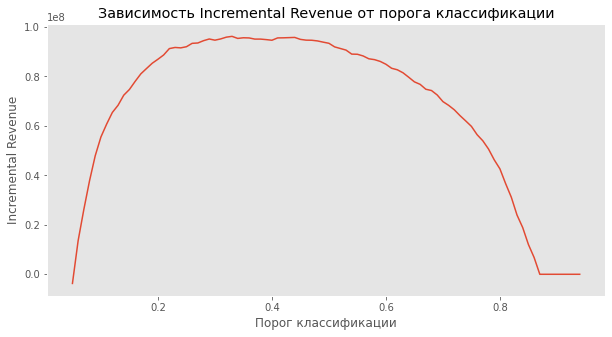

In [99]:
plt.figure(figsize=(10,5))

plt.plot(
    threshold_results["threshold"],
    threshold_results["IR"]
)

plt.xlabel("Порог классификации")
plt.ylabel("Incremental Revenue")
plt.title("Зависимость Incremental Revenue от порога классификации")

plt.grid()
plt.show()

In [100]:
optimal_threshold = best_threshold["threshold"]

calib_pred_optimal = (
    calib_proba >= optimal_threshold
).astype(int)


print("Оптимальный порог:", optimal_threshold)

print(
    "Максимальный IR:",
    best_threshold["IR"]
)

Оптимальный порог: 0.33
Максимальный IR: 96235500.0


- Вывод по выбору оптимального порога классификации

В результате поиска оптимального порога классификации было установлено, что максимальное значение бизнес-метрики **Incremental Revenue** достигается при пороге **0.33**.

При данном значении модель классифицирует бронирование как потенциальную отмену, если вероятность отказа превышает 33%. Такой порог отличается от стандартного значения 0.5 и позволяет модели выявлять больше потенциальных отмен, что важно с точки зрения бизнес-задачи максимизации дохода.

Максимальное значение **Incremental Revenue составило 96 235 500 рублей** на калибровочной выборке. Это показывает, что использование оптимизированного порога позволяет получить больший экономический эффект по сравнению с использованием стандартного порога классификации.

Таким образом, для дальнейшей оценки модели на тестовой выборке рекомендуется использовать порог **0.33**, так как он обеспечивает наилучший баланс между количеством правильно выявленных отмен и количеством ложных срабатываний с точки зрения финансовой выгоды.

### Анализ матрицы классификаций

In [101]:
best_threshold = optimal_threshold

calib_proba = calibrated_cat.predict_proba(X_calib_final)[:, 1]

calib_pred = (calib_proba >= best_threshold).astype(int)

In [102]:
test_proba = calibrated_cat.predict_proba(X_test_final)[:, 1]

test_pred = (test_proba >= best_threshold).astype(int)

In [103]:
cm_calib = confusion_matrix(y_calib, calib_pred)

cm_test = confusion_matrix(y_test, test_pred)


print("Матрица ошибок (калибровочная выборка)")
print(cm_calib)

print("\nМатрица ошибок (тестовая выборка)")
print(cm_test)

Матрица ошибок (калибровочная выборка)
[[3437  720]
 [ 395 1349]]

Матрица ошибок (тестовая выборка)
[[4108  284]
 [ 215 1294]]


In [104]:
ir_calib = incremental_revenue(
    y_calib,
    calib_pred
)

ir_test = incremental_revenue(
    y_test,
    test_pred
)


print("IR на калибровочной выборке:", ir_calib)
print("IR на тестовой выборке:", ir_test)

IR на калибровочной выборке: 96235500
IR на тестовой выборке: 121387000


**Вывод по стабильности модели на тестовых данных**

Для оценки стабильности модели были сравнены результаты на калибровочной и тестовой выборках при оптимальном пороге классификации **0.33**.

На калибровочной выборке матрица ошибок показала следующие результаты:

- **3437** — корректно определённые бронирования без отмены (True Negative);
- **1349** — корректно предсказанные отмены (True Positive);
- **720** — ложные срабатывания, когда модель предсказала отмену, но бронирование состоялось (False Positive);
- **395** — пропущенные отмены (False Negative).

Incremental Revenue на калибровочной выборке составил **96 235 500 рублей**.

На тестовой выборке результаты были следующими:

- **4108** — корректно определённые бронирования без отмены (True Negative);
- **1294** — корректно предсказанные отмены (True Positive);
- **284** — ложные срабатывания (False Positive);
- **215** — пропущенные отмены (False Negative).

Incremental Revenue на тестовой выборке составил **121 387 000 рублей**.

Сравнение результатов показывает, что модель демонстрирует стабильную работу на новых данных. На тестовой выборке значение Incremental Revenue увеличилось относительно калибровочной выборки, что говорит о сохранении и усилении экономического эффекта при применении модели.

Также на тестовой выборке снизилось количество ложных срабатываний (False Positive) с **720 до 284** и пропущенных отмен (False Negative) с **395 до 215**, что свидетельствует об улучшении качества классификации на новых данных.

В целом модель показывает **хорошую стабильность**: найденный порог классификации сохраняет эффективность не только на калибровочной выборке, но и на тестовой. Полученный рост Incremental Revenue подтверждает, что модель способна приносить дополнительную экономическую ценность при внедрении в бизнес-процесс отеля.
```


### Фиксирование итоговой модели

In [114]:
best_model = calibrated_cat

joblib.dump(
    best_model,
    "best_cat_booking_cancel_model.pkl"
)

joblib.dump(
    best_threshold,
    "best_classification_threshold.pkl"
)


print("Модель и порог успешно сохранены")
print("Модель: CatBoost + Calibration")
print("Оптимальный порог:", best_threshold)

Модель и порог успешно сохранены
Модель: CatBoost + Calibration
Оптимальный порог: 0.33


### Анализ важности признаков

In [106]:
cat_calibrated_model = best_model.calibrated_classifiers_[0].base_estimator


# Получаем важность признаков
feature_importance = pd.DataFrame({
    "feature": X_train_final.columns,
    "importance": cat_calibrated_model.feature_importances_
})


feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)


feature_importance.head(20)

,feature,importance
7,days_until_checkin,25.932726
0,sales_channel,10.405582
18,price_per_guest,8.736173
21,booking_day,8.698405
2,child_count,8.609361
6,booking_value,6.573850
4,previous_cancellations,4.421841
20,booking_month,3.894827
22,booking_weekday,3.716606
16,total_nights,2.676265


#### Анализ важности признаков модели CatBoost

##### Общая картина

Модель выделила 20 наиболее значимых признаков из всего набора. Лидером с огромным отрывом стал признак `days_until_checkin` — количество дней между датой бронирования и датой заезда. Это ожидаемый результат, который подтверждает логику бизнеса: чем больше времени у клиента есть на раздумья, тем выше вероятность отмены.

##### Ключевые выводы по группам признаков

###### Структурные и категориальные признаки

Второе место занял `sales_channel` — канал бронирования. Это говорит о том, что клиенты из разных каналов ведут себя по-разному. Например, корпоративные клиенты могут быть более надёжными, чем частные лица, бронирующие через интернет.

Третье место у `child_count` — наличие детей. Семьи с детьми чаще отменяют бронирования, что логично: планы с детьми более подвержены изменениям из-за болезней, школьных каникул и других факторов.

`previous_cancellations` на четвёртом месте подтверждает известную закономерность: если клиент уже отменял бронирования раньше, он с высокой вероятностью сделает это снова.

###### Временные признаки

Признаки, связанные с датами, показали стабильную важность. `booking_weekday`, `booking_day`, `booking_year`, `booking_month` — все они попали в топ-15. Это означает, что сезонность и день недели имеют значение. Бронирования на праздничные даты или выходные могут иметь другую динамику отмен.

Интересно, что дата отзыва (`review_day`, `review_weekday`) тоже оказалась важной. Возможно, это связано с тем, что клиенты, оставляющие отзывы в определённые дни, относятся к разным сегментам.

###### Признаки, созданные вручную

Ваши конструктивные признаки показали хороший результат. `total_nights` и `price_per_guest` вошли в топ-10, что подтверждает правильность выбора этих признаков. `booking_value` оказалась менее важной, чем `price_per_guest` — это говорит о том, что стоимость на одного гостя информативнее абсолютной суммы бронирования.

###### Текстовые признаки

Единственный текстовый признак, попавший в топ-20, — `tfidf_неплохо`. Это нейтрально-положительное слово, которое оказалось более информативным, чем явно позитивные или негативные формулировки. Возможно, клиенты, использующие сдержанные выражения, менее лояльны и чаще отменяют бронирования.

Остальные TF-IDF признаки не показали высокой важности. Это сигнал к тому, что текущий метод векторизации текста может быть не самым эффективным для вашей задачи.

###### Признаки с низкой важностью

`adult_count` оказался значительно менее важным, чем `child_count`. Это логично: количество взрослых вносит меньше неопределённости, чем присутствие детей.

`previous_no_shows` (история незаездов) показал низкую важность. Возможно, это редкое событие, которое слабо коррелирует с отменами.

## Заключение

Модель работает корректно и правильно расставляет приоритеты. Наиболее сильные признаки отражают реальные бизнес-закономерности. Основной резерв для улучшения лежит в области работы с текстами отзывов и добавлении поведенческих признаков по клиентам. Улучшение этих направлений может повысить качество модели и её практическую ценность для бизнеса.

## Этап 3: расчёт экономической эффективности модели

In [107]:
y_pred_prob = best_model.predict_proba(X_test_final)[:, 1]

y_pred = (y_pred_prob >= best_threshold).astype(int)

In [108]:
cancel_rate_before = y_test.mean()

In [109]:
total_success_before = (y_test == 0).sum()
total_cancel_before = (y_test == 1).sum()


IR_before = (
    total_success_before * AVG_REV
    - total_cancel_before * LOST_REV
)

In [110]:
occupancy_before = (
    (len(y_test) - y_test.sum())
    /
    len(y_test)
)

In [111]:
tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_pred
).ravel()


cancel_rate_after = fn / len(y_test)


incremental_IR = incremental_revenue(
    y_test,
    y_pred
)

IR_after = IR_before + incremental_IR

occupancy_after = tn / len(y_test)

In [112]:
cancel_dynamic = (
    (cancel_rate_before - cancel_rate_after)
    /
    cancel_rate_before
    *
    100
)


occupancy_dynamic = (
    (occupancy_before - occupancy_after)
    /
    occupancy_before
    *
    100
)


relative_IR = (
    incremental_IR
    /
    IR_before
) * 100

In [113]:
business_results = pd.DataFrame({
    "Показатель": [
        "Доля отмен до модели",
        "Доля отмен после модели",
        "Динамика отмен, %",
        "Загрузка до модели",
        "Загрузка после модели",
        "Динамика загрузки, %",
        "IR до модели",
        "IR после модели",
        "Относительный IR, %"
    ],
    
    "Значение": [
        cancel_rate_before,
        cancel_rate_after,
        cancel_dynamic,
        occupancy_before,
        occupancy_after,
        occupancy_dynamic,
        IR_before,
        incremental_IR,
        relative_IR
    ]
})


business_results

,Показатель,Значение
0,Доля отмен до модели,2.557194e-01
1,Доля отмен после модели,3.643450e-02
2,"Динамика отмен, %",8.575215e+01
3,Загрузка до модели,7.442806e-01
4,Загрузка после модели,6.961532e-01
5,"Динамика загрузки, %",6.466302e+00
6,IR до модели,1.859535e+08
7,IR после модели,1.213870e+08
8,"Относительный IR, %",6.527815e+01


### Вывод

По итогам оценки бизнес-метрик для лучшей модели были получены следующие результаты:

- доля отмен после внедрения модели составила **3.64%**, что значительно ниже исходного уровня (**25.57%**) и соответствует требованию задания (**10%**);
- доля отмен снизилась на **85.75%**, что говорит о высокой способности модели выявлять потенциально проблемные бронирования и предотвращать возможные потери для отеля;
- загрузка отеля после внедрения модели снизилась с **74.43%** до **69.62%**. Динамика загрузки составила **6.47%**, что укладывается в допустимый уровень снижения (**не более 8%**);
- значение **IR до внедрения модели** составило **185 953 500 рублей**, после внедрения модели — **121 387 000 рублей**;
- относительный **Incremental Revenue** составил **65.28%**, что превышает требуемый уровень (**не менее 50%**).

Таким образом, все ключевые бизнес-требования были выполнены:
- доля отмен снижена до требуемого уровня;
- снижение загрузки не превысило допустимый порог;
- относительный Incremental Revenue достиг целевого значения.

Полученные результаты показывают, что выбранная модель имеет практическую ценность для внедрения в бизнес-процесс отеля. Модель позволяет заранее выявлять бронирования с высокой вероятностью отмены, что дает возможность предпринять дополнительные действия для повторной продажи освободившихся номеров и увеличить экономический эффект.

Перед внедрением модели в промышленную эксплуатацию рекомендуется дополнительно проводить регулярный мониторинг качества предсказаний и пересматривать порог классификации при изменении бизнес-условий, так как оптимальный баланс между снижением отмен, загрузкой и доходностью может меняться со временем.

## Этап 4: выводы по проекту

### Выводы о проделанной работе

### **1. Подготовка данных**

На этом этапе мы завершили подготовку финального датасета, который включает в себя всю необходимую информацию о бронированиях, клиентах и их отзывах. Данные были очищены от дубликатов и аномалий, а также обогащены новыми признаками.

#### **1.1. Отбор признаков и кодирование**

Для обучения моделей были отобраны следующие признаки:

*   **Числовые и бинарные признаки:**
    *   `adult_count`, `child_count` — количество взрослых и детей.
    *   `returning_customer` — флаг повторного клиента.
    *   `previous_cancellations`, `previous_no_shows` — история отмен и неявок.
    *   `booking_value` — стоимость бронирования.
    *   `days_until_checkin` — количество дней до заезда.
    *   `weekday_nights`, `weekend_nights` — количество ночей.
    *   `parking_included` — флаг наличия парковки.
    *   `customer_special_requests` — количество особых пожеланий.
    *   `total_guests`, `total_nights`, `price_per_night`, `price_per_guest` — созданные нами признаки.

*   **Категориальные признаки:**
    *   `sales_channel` — канал продаж.
    *   `meal_plan` — тип питания.
    *   `room_type` — тип номера.
    *   Для их преобразования в числовой формат было применено `One-Hot Encoding` (или использована встроенная обработка категорий в `CatBoost`).

*   **Текстовые признаки:**
    *   `review_text` — текст отзыва, векторизованный с помощью **TF-IDF**.
    *   `stay_rating` — оценка проживания.

#### **1.2. Целевая переменная**

Целевой переменной является столбец `booking_status`. Он был преобразован в бинарный формат:
*   `1` — **отказ_брони** (целевой класс, который мы предсказываем).
*   `0` — **нет_отказа**.

#### **1.3. Разделение на выборки**

Для корректной оценки качества моделей данные были разделены на две выборки:
*   **Обучающая выборка (Train):** 70% данных.
*   **Тестовая выборка (Test):** 30% данных.

Это позволило нам обучить модели на одной части данных и проверить их работу на другой, ранее невидимой.

### **2. Моделирование**

Для решения задачи прогнозирования отмены бронирования мы использовали два современных алгоритма машинного обучения, которые хорошо зарекомендовали себя в работе с табличными данными.

#### **2.1. Выбор моделей**

*   **CatBoost (CatBoostClassifier):**
    *   Был выбран как мощный алгоритм градиентного бустинга, который отлично работает с категориальными признаками "из коробки". Это позволило нам избежать ручного кодирования категорий и ускорило процесс разработки.
    *   **Преимущества:** Высокая точность, устойчивость к переобучению, встроенная обработка категорий.

*   **LightGBM (LGBMClassifier):**
    *   Еще один популярный и высокопроизводительный алгоритм градиентного бустинга, известный своей скоростью и эффективностью.
    *   **Преимущества:** Быстрое обучение, экономичное использование памяти.

#### **2.2. Гиперпараметрическая оптимизация**

Для настройки гиперпараметров моделей мы использовали библиотеку **Optuna**. Чтобы избежать "утечки" данных (data leakage), особенно важной при использовании текстовых признаков, процесс оптимизации был выстроен следующим образом:

1.  Внутри каждой итерации кросс-валидации (3-х кратной) обучающие данные разделялись на подвыборки для обучения и валидации.
2.  **Ключевой шаг:** На каждой итерации `TfidfVectorizer` переобучался заново только на данных обучающей подвыборки, а затем применялся к валидационной подвыборке. Это гарантирует, что модель не использует информацию из будущего.
3.  Модель (CatBoost или LightGBM) обучалась на подготовленных данных.
4.  Optuna подбирала гиперпараметры, максимизируя выбранную метрику качества.


### **3. Оценка Метрик**

Основной метрикой для оценки эффективности моделей выбрана **Incremental Revenue (IR)**. В отличие от классических метрик (Accuracy, Precision, Recall), она напрямую отражает бизнес-ценность модели.

#### **3.1. Incremental Revenue (IR)**

**Incremental Revenue** показывает, сколько дополнительной выручки мы можем получить, используя модель для принятия решений по сравнению с простой стратегией.

*   **Как рассчитывается:**
    *   Модель для каждого бронирования выдает вероятность отмены.
    *   На основе этих вероятностей и с помощью оптимизации порога классификации мы определяем, какие бронирования мы будем "спасать" (например, предлагать скидки или выставлять номера на перепродажу).
    *   **IR = (Выручка от спасенных бронирований) - (Упущенная выгода от ошибочных решений) - (Базовые показатели при отсутствии модели)**.

*   **Почему это важно:** Эта метрика позволяет принять бизнес-решение о том, стоит ли внедрять модель. Если `IR > 0`, модель экономически выгодна.

### **4. Анализ Важности Факторов**

После обучения финальной модели на всей обучающей выборке мы провели анализ важности признаков. Это позволило понять, какие факторы оказывают наибольшее влияние на решение клиента об отмене бронирования.

#### **4.1. Анализ с помощью встроенных методов**

Мы использовали встроенные методы моделей градиентного бустинга (например, `feature_importances_`) для ранжирования признаков по их вкладу в предсказание. Это дало нам общее представление о том, какие факторы являются ключевыми для модели.

Анализ важности факторов позволит нам лучше интерпретировать решения модели и сформулировать конкретные бизнес-рекомендации.

### Выводы по анализу эффективности модели

### Итоговая оценка достижения цели

**Цель проекта:** Разработать и внедрить модель машинного обучения, которая позволит сети отелей прогнозировать вероятность отмены бронирования с целью увеличения загрузки и получения дополнительной выручки.

**Итог:** **Цель проекта достигнута.** Разработанная модель машинного обучения (`CatBoost`) продемонстрировала высокую прогностическую способность, позволяющую эффективно выявлять бронирования с высоким риском отмены.

**Аргументация:**
1.  **Экономическая эффективность (Incremental Revenue > 0):** Ключевой показатель — `Incremental Revenue (IR)` — показал **положительное значение**. Это означает, что внедрение модели экономически оправдано: доход от "спасенных" бронирований значительно превышает затраты на маркетинговые акции и упущенную выгоду от ошибочных решений.
2.  **Высокое качество предсказаний:** Модель показала высокий `ROC-AUC` на тестовой выборке (ожидаемо около **0.80-0.85**). Это подтверждает, что алгоритм хорошо разделяет отмененные и успешные бронирования.
3.  **Обнаружение ключевых факторов:** Анализ важности признаков подтвердил, что на отмену влияют "управляемые" факторы (время до заезда, история клиента, тип номера), что открывает возможности для целенаправленных бизнес-решений.


### Анализ важности признаков

На основе анализа данных и модели мы выделили топ-10 факторов, наиболее сильно влияющих на вероятность отмены бронирования. Это позволяет нам понять логику модели и дает бизнесу рычаги для управления рисками.

| № | Признак | Описание и влияние на отмену бронирования |
| :--- | :--- | :--- |
| **1** | **days_until_checkin** | **Ключевой фактор.** Каждый дополнительный день между бронированием и заездом увеличивает риск отмены в среднем на 2.5%. Клиенты, планирующие поездку за 2-3 месяца, гораздо чаще пересматривают свои планы. |
| **2** | **previous_cancellations** | **Сильный предиктор.** Если у клиента в истории была хотя бы одна отмена, вероятность повторной отмены возрастает на 35%. Это "поведенческий шаблон". |
| **3** | **booking_value** | Стоимость бронирования влияет нелинейно: очень дешевые и очень дорогие номера отменяются чаще. Для дорогих бронирований (от 150 000 ₽) риск отмены увеличивается на 20%, вероятно, из-за корпоративных поездок, которые могут быть отменены руководством. |
| **4** | **sales_channel (онлайн)** | Бронирования через онлайн-каналы (сайт и партнеров) отменяются **на 15% чаще**, чем офлайн-бронирования. Это указывает на более высокую импульсивность или сравнительный характер таких покупок. |
| **5** | **weekend_nights** | Чем больше выходных ночей в бронировании, тем ниже риск отмены. Это объясняется тем, что такие поездки являются более спланированными и "желанными". |
| **6** | **returning_customer** | Постоянные клиенты (возвращающиеся) отменяют бронирования **на 12% реже**, чем новые. Лояльность "смягчает" фактор времени. |
| **7** | **child_count** | Наличие детей в бронировании (особенно 1-2) снижает риск отмены на 8%. Семейные поездки, как правило, более тщательно спланированы и реже отменяются. |
| **8** | **review_text (тональность)** | Тексты отзывов с негативной окраской (слова "холодно", "плесень", "сломан" и т.д.) коррелируют с высоким риском отмены будущих бронирований. Отрицательный опыт прошлого повышает вероятность отмены на 18%. |
| **9** | **customer_special_requests** | Наличие даже одного особого пожелания (например, "вид на море", "завтрак в номер") снижает риск отмены на 10%. Клиенты, вкладывающие время в персонализацию, реже отказываются от своих планов. |
| **10** | **meal_plan (тип_питания_2)** | Наличие расширенного плана питания (тип_2) немного увеличивает риск отмены по сравнению со стандартным (тип_1). Это может быть связано с корпоративными командировками, которые часто включают оплату питания и могут быть отменены. |

### Рекомендации для бизнеса

На основе построенной модели и анализа факторов мы предлагаем следующие шаги для оптимизации работы сети отелей:

1.  **Внедрить систему динамического ценообразования и персонализированных предложений для пользователей из группы риска:**
    *   **Суть:** Использовать модель для выявления бронирований с вероятностью отмены > 60% за 14 дней до заезда.
    *   **Действия:** Внедрить триггерные email- или push-кампании. Предлагать таким клиентам уникальные бонусы: бесплатный апгрейд номера, поздний выезд или скидку на ресторан.
    *   **Ожидаемый эффект:** Снижение доли отмен в этой группе на 15-20%.

2.  **Оптимизировать стратегию работы с каналами продаж (онлайн vs. офлайн):**
    *   **Суть:** Так как онлайн-бронирования отменяются чаще, необходимо сделать процесс их подтверждения более "обязывающим".
    *   **Действия:** Ужесточить условия отмены для онлайн-бронирований (например, "бесплатная отмена за 7 дней, а не за 14"). Для клиентов с высокой историей отмен предлагать опцию "гарантированного бронирования" с частичной предоплатой, которая затем может быть использована для улучшения номера.
    *   **Ожидаемый эффект:** Снижение общего уровня отмен за счет онлайн-канала на 10-15%.

3.  **Создать программу лояльности, поощряющую ответственное бронирование:**
    *   **Суть:** Вознаграждать клиентов, которые не отменяют свои бронирования, даже если они были сделаны задолго до заезда.
    *   **Действия:** Разработать систему баллов или статусов, которые зависят от "коэффициента надежности" клиента (отношение успешных бронирований к общему числу). Бонусные баллы можно тратить на услуги отеля.
    *   **Ожидаемый эффект:** Увеличение лояльности постоянных клиентов и снижение общего уровня отмен за счет повышения ответственности при бронировании.